# Group 1 Project Notebook

## Problem definition and objectives

The purpose of our project is to understand the relationship between crime in English regions and their index of multiple deprivation. Our hypothesis is that areas with higher levels of deprivation (the closer to 1 they are ranked the more deprived they are) are more likely to experience higher levels of crime.

Whilst the primary focus of this project was the relationship between crime and deprivation, we also explored selected ONS wellbeing indicators to investigate whether similar regional patterns were observed beyond the IMD framework. This provided additional context for interpreting regional differences in recorded crime and allowed comparisons between deprivation and broader measures of wellbeing.

The IMD data comes out every four - five years so by completing our analysis and then building a machine learning model which predicts the IMD score for an ITL2 region, based on the level of crime it has experienced that year we aim to provide annual estimates for local (ITL2 regions) areas based on our model.

This matters for both the police and local authorities and can help with future planning for care by local authorities. Additionally, the broader wellness data helps to give another dimension of detail which can help to inform the level of crime and impact on deprivation within an area. This can help local authorities ensure both enforcement and medical help are provided.

## Importing Packages
The following packages need to be imported to run our code.

In [92]:
from pathlib import Path
import pandas as pd
import numpy as np
import statistics 
import openpyxl 
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,\
root_mean_squared_error, mean_absolute_error
import geopandas as gpd

## Data Cleaning and Preprocessing

- Crime
    Key Tasks:
    - Focus on the 2025 data
    - Group by location (ITl1 regions and ITl2 regions)
    - Remove Wales data
    - Remove national police forces / create a new data field for that
- Index of Multiple Deprivation
    - Investigated data (type of data, missing values)
    - Removed any unneccessary columns
    - Mapped LAD codes to ITLs

- Wellness Data

#### Crime cleaning

Below is the process we undertook to clean the crime data as well as a few notes.

In [93]:
# Uploading the crime data
df_2025 = pd.read_excel("old_data/old_historical_crime_data.xlsx",
              sheet_name="2024_25",
              index_col=0)



# Investigating if there are any outliers, although we decided to include all offences for the relevant regions.
data = df_2025.loc[:,"Number of Offences"]

def find_outliers_iqr(data):
    """" The purpose of this function is to detect whether or not there are outliers within the crime data, particularly around the number of offences."""
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data >
    upper_bound)]
    return f"Here are the outliers: {outliers}, the lower bound: {lower_bound} and the upper bounds {upper_bound}."

find_outliers_iqr(data)



# Investigating data types and assessing if they are the most appropriate for the values
print(f'\nAll data types for the Crime dataset: \nFinancial Quarter: {df_2025['Financial Quarter'].dtypes}\
\nForce Name: {df_2025['Force Name'].dtypes}\nOffence Description: {df_2025['Offence Description'].dtypes}\
\nOffence Group: {df_2025['Offence Group'].dtypes}\nOffence Subgroup: \
{df_2025['Offence Subgroup'].dtypes}\
\nOffence Code: {df_2025['Offence Code'].dtypes}\nNumber of Offences: {df_2025['Number of Offences'].dtypes}')

df_copy = df_2025.copy()
df_copy.duplicated(subset='Force Name')
df_copy.duplicated(subset='Force Name').sum()
df_copy.drop_duplicates(subset='Force Name', inplace=True) # Want to know all of the unique force names so that I can find out which regions they belong to
# print(df_copy["Force Name"])

print(df_copy.info())



All data types for the Crime dataset: 
Financial Quarter: int64
Force Name: str
Offence Description: str
Offence Group: str
Offence Subgroup: str
Offence Code: str
Number of Offences: int64
<class 'pandas.DataFrame'>
Index: 47 entries, 2024/25 to 2024/25
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Financial Quarter    47 non-null     int64
 1   Force Name           47 non-null     str  
 2   Offence Description  47 non-null     str  
 3   Offence Group        47 non-null     str  
 4   Offence Subgroup     47 non-null     str  
 5   Offence Code         47 non-null     str  
 6   Number of Offences   47 non-null     int64
dtypes: int64(2), str(5)
memory usage: 2.9+ KB
None


In [94]:
# Uploading the crime data
df_2025 = pd.read_excel("old_data/old_historical_crime_data.xlsx",
              sheet_name="2024_25",
              index_col=0)

print(df_2025.info()) # To understand the data before it has been changed / modified
print(f'\nPre-cleaning summary statistics:\n{df_2025.describe()}')


# Checking for missing values, with none found across all columns
missing_values = df_2025.isnull().sum()
print(f'Total missing values for the Crime dataset: {missing_values.sum()}')

# Investigating if there are any outliers, although we decided to include all offences for the relevant regions.
data = df_2025.loc[:,"Number of Offences"]

def find_outliers_iqr(data):
    """" The purpose of this function is to detect whether or not there are outliers within the crime data, particularly around the number of offences."""
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data >
    upper_bound)]
    return f"Here are the outliers: {outliers}, the lower bound: {lower_bound} and the upper bounds {upper_bound}."

find_outliers_iqr(data)


# Investigating data types and assessing if they are the most appropriate for the values
print(f'\nAll data types for the Crime dataset: \nFinancial Quarter: {df_2025['Financial Quarter'].dtypes}\
\nForce Name: {df_2025['Force Name'].dtypes}\nOffence Description: {df_2025['Offence Description'].dtypes}\
\nOffence Group: {df_2025['Offence Group'].dtypes}\nOffence Subgroup: \
{df_2025['Offence Subgroup'].dtypes}\
\nOffence Code: {df_2025['Offence Code'].dtypes}\nNumber of Offences: {df_2025['Number of Offences'].dtypes}')

# Here I am working out which are the unique locations so I can map to the ITL1 and ITL2 regions
df_copy = df_2025.copy()
df_copy.duplicated(subset='Force Name')
df_copy.duplicated(subset='Force Name').sum()
df_copy.drop_duplicates(subset='Force Name', inplace=True) # Want to know all of the unique force names so that I can find out which regions they belong to
print(df_copy["Force Name"]) # Prints all Police names so I can find out which region they're in. I did this through a manual search using this website - https://www.ons.gov.uk/methodology/geography/ukgeographies/eurostat

# Need to clean the data from Force Name
ITL_1_matches = { # Note I don't have any Scotland or Northern Ireland data due to the various devolved powers. I have mapped the Welsh and national english forces but will remove these at a later stage, so that a deep dive of english regional data only can be done.
    "Avon and Somerset": "South West (England)",
    "Bedfordshire": "East (England)",
    "British Transport Police": "UK",
    "Cambridgeshire": "East (England)",
    "Cheshire": "North West (England)",
    "Cleveland": "North East (England)",
    "Cumbria": "North West (England)",
    "Derbyshire": "East Midlands",
    "Devon and Cornwall": "South West (England)",
    "Dorset": "South West (England)",
    "Durham": "North East (England)",
    "Dyfed-Powys": "Wales",
    "Essex": "East (England)",
    "Gloucestershire": "South West (England)",
    "Greater Manchester": "North West (England)",
    "Gwent": "Wales",
    "Hampshire": "South East (England)",
    "Hertfordshire": "East (England)",
    "Humberside": "Yorkshire and The Humber",
    "Kent": "South East (England)",
    "Lancashire": "North West (England)",
    "Leicestershire": "East Midlands",
    "Lincolnshire": "East Midlands",
    "London, City of": "London",
    "Merseyside": "North West (England)",
    "Metropolitan Police": "London",
    "Norfolk": "East (England)",
    "North Wales": "Wales",
    "North Yorkshire": "Yorkshire and The Humber",
    "Northamptonshire": "East Midlands",
    "Northumbria": "North East (England)",
    "Nottinghamshire": "East Midlands",
    "South Wales": "Wales",
    "South Yorkshire": "Yorkshire and The Humber",
    "Staffordshire": "West Midlands",
    "Suffolk": "East (England)",
    "Surrey": "South West (England)",
    "Sussex": "South East (England)",
    "Thames Valley": "South East (England)",
    "Warwickshire": "West Midlands",
    "West Midlands": "West Midlands",
    "West Mercia": "West Midlands",
    "West Yorkshire": "Yorkshire and The Humber",
    "Wiltshire": "South West (England)",
    "Action Fraud": "UK",
    "CIFAS": "UK",
    "UK Finance": "UK"
    }

df_2025["ITL1 region"] = df_2025["Force Name"].map(ITL_1_matches) # Mapping regions to the various police forces


print(df_2025["ITL1 region"].isnull().sum()) # To test every police force has been mapped to make sure there are no null values
print(df_2025["ITL1 region"].info()) # To test every police force has been mapped by counting the number of rows in this column vs the document


# Our other data doesn't have Wales in it and as there is no Scotland or Northern Irish data it is best to stick to England. Therefore I have deleted Wales from the dataset

updated_df = df_2025.copy() #Making a copy which is where I remove a lot of unnecessary data (e.g. Wales and national police forces)

welsh_forces = updated_df[updated_df["ITL1 region"] == "Wales"] # Filtering to only include Wales forces

# Can be removed but an example of filtering data to only Welsh forces
welsh_forces.drop_duplicates(subset='ITL1 region', inplace=True) # Removing all with Wales
welsh_forces.reset_index(inplace=True) # Setting the index to numbers so its easy to remove
welsh_forces.drop(0, inplace=True) # Now I have no welsh forces in this filter
# updated_df.info()


updated_df.loc[updated_df["ITL1 region"] == "Wales", "ITL1 region"] = None # Making this null values so I can remove the data
updated_df.dropna(inplace=True) # Removing Welsh data
print(updated_df.info()) # Checking to make sure it has been removed

# Adding in ITL2 information


ITL_2_matches = {
    "Avon and Somerset": "West of England;North Somerset, Somerset and Dorset",
    "Bedfordshire": "Bedfordshire and Hertfordshire",
    "British Transport Police": "UK",
    "Cambridgeshire": "Cambridgeshire and Peterborough",
    "Cheshire": "Cheshire",
    "Cleveland": "Tees Valley",
    "Cumbria": "Cumbria",
    "Derbyshire": "Derbyshire and Nottinghamshire",
    "Devon and Cornwall": "Devon;Cornwall and Isles of Scilly",
    "Dorset": "North Somerset, Somerset and Dorset",
    "Durham": "Northumberland, Durham and Tyne & Wear",
    "Dyfed-Powys": "Mid and South West Wales",
    "Essex": "Essex",
    "Gloucestershire": "Gloucestershire and Wiltshire",
    "Greater Manchester": "Greater Manchester",
    "Gwent": "South East Wales",
    "Hampshire": "Hampshire and Isle of Wight",
    "Hertfordshire": "Bedfordshire and Hertfordshire",
    "Humberside": "East Yorkshire and Northern Lincolnshire",
    "Kent": "Kent",
    "Lancashire": "Lancashire",
    "Leicestershire": "Leicestershire, Rutland and Northamptonshire",
    "Lincolnshire": "Lincolnshire",
    "London, City of": "Inner London - West",
    "Merseyside": "Merseyside",
    "Metropolitan Police": "Inner London - West;Inner London - East;Outer London - East and North East;Outer London - South;Outer London - West and North West",
    "Norfolk": "Norfolk",
    "North Wales": "North Wales",
    "North Yorkshire": "North Yorkshire",
    "Northamptonshire": "Leicestershire, Rutland and Northamptonshire",
    "Northumbria": "Northumberland, Durham and Tyne & Wear",
    "Nottinghamshire": "Derbyshire and Nottinghamshire",
    "South Wales": "South East Wales;Mid and South West Wales",
    "South Yorkshire": "South Yorkshire",
    "Staffordshire": "Shropshire and Staffordshire",
    "Suffolk": "Suffolk",
    "Surrey": "Surrey, East and West Sussex",
    "Sussex": "Surrey, East and West Sussex",
    "Thames Valley": "Berkshire, Buckinghamshire and Oxfordshire",
    "Warwickshire": "Herefordshire, Worcestershire and Warwickshire",
    "West Mercia": "Shropshire and Staffordshire;Herefordshire, Worcestershire and Warwickshire",
    "West Midlands": "West Midlands",
    "West Yorkshire": "West Yorkshire",
    "Wiltshire": "Gloucestershire and Wiltshire",
    "Action Fraud": "UK",
    "CIFAS": "UK",
    "UK Finance": "UK",
}

updated_df["ITL2 region"] = updated_df["Force Name"].map(ITL_2_matches) # Mapping the ITL2 regions if we would like them
# print(updated_df.head(3)) # Checking to make sure it ran correctly
print(updated_df.info())


national_forces = updated_df[updated_df["ITL1 region"] == "UK"]
national_forces.reset_index(inplace=True)
national_forces.to_csv("clean_materials/CLEANED-national_forces_crime_data_2024-2025.csv") # Creating new data set

print(updated_df.info())
# Removing from regional data set
updated_df.loc[updated_df["ITL1 region"] == "UK", "ITL1 region"] = None # Making this null values so I can remove the data
updated_df.dropna(inplace=True) # Removing UK data
print(updated_df.info()) # Checking to make sure it has removed
print(updated_df[updated_df["ITL1 region"] == "UK"]) # DOuble checking there are no more of these rows

updated_df.reset_index(inplace=True) # Creating an index which is numbers based
updated_df.to_csv("clean_materials/CLEANED-regional_forces_crime_data_2024-2025.csv") # Saving the cleaned data
crime_df = updated_df

print(f'\nPost-cleaning summary statistics:\n{crime_df.describe()}')

<class 'pandas.DataFrame'>
Index: 25356 entries, 2024/25 to 2024/25
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Financial Quarter    25356 non-null  int64
 1   Force Name           25356 non-null  str  
 2   Offence Description  25356 non-null  str  
 3   Offence Group        25356 non-null  str  
 4   Offence Subgroup     25356 non-null  str  
 5   Offence Code         25356 non-null  str  
 6   Number of Offences   25356 non-null  int64
dtypes: int64(2), str(5)
memory usage: 1.5+ MB
None

Pre-cleaning summary statistics:
       Financial Quarter  Number of Offences
count       25356.000000        25356.000000
mean            2.500000          259.852776
std             1.118056         2527.993452
min             1.000000            0.000000
25%             1.750000            0.000000
50%             2.500000           11.000000
75%             3.250000          103.000000
max             4.0000

#### Crime Data Cleaning Reasoning
- Outliers: The outliers identified were identified through the locations they were grouped in rather than the number of crimes committed.


- Deleting rows: We decided to delete any rows mentioning Wales or UK wide data because the focus of this analysis was only on England as we had datasets for all for England, while we were missing some for Scotland, Wales and Northern Ireland.





#### IMD cleaning

Below is the process we undertook to clean the IMD data, as well as notes to explain why we did this:
- Investigated data (type of data, missing values)
- Removed any unneccessary columns
- Mapped LAD codes to ITLs

The ITL1 and ITL2 regions can then be utilised across the datasets for this project, ensuring that location data is directly comparable. This is necessary as, for example, the police dataset utilises police districts that are not directly comparable to LSOAs or LADs.

##### A note on the data:
The Index of Multiple Deprivation (IMD) dataset was published by the Ministry of Housing, Communities & Local Government (MHCLG) and was constructed by Oxford Consultants for Social Inclusion (OCSI) and Deprivation.org. This dataset was downloaded from the GOV.UK website, as an Excel file (.xlsx), using the link 'https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025' on 9th June 2026. The official statistics on the source website were published on 30 October 2025 and last updated on 17 November 2025.
**The above can probably be deleted, as its in the README and report** **maybe we check that this has been kept in report fully, first**

An additional dataset has also been utilised, to support the preprocessing of the IMD dataset, the necessity of which is detailed fully later in this notebook. In brief, the 'Local Authority District (December 2024) to LAU1 to ITL3 to ITL2 to ITL1 (January 2025) Lookup in the UK' dataset is required for standardising the location data of the IMD dataset, to allow comparison to other datasets (such as the ‘Police recorded crime open data tables, year ending March 2013 onwards’ dataset) and improve overall ease of understanding.

The 'Local Authority District (December 2024) to LAU1 to ITL3 to ITL2 to ITL1 (January 2025) Lookup in the UK' dataset was published by the Office for National Statistics (ONS). The dataset was downloaded from the National Data Library website, as a csv file (.csv), using the link 'https://www.data.gov.uk/dataset/2b47adcc-62b6-4dd3-a6cb-271b3035e9fd/local-authority-district-december-2024-to-lau1-to-itl3-to-itl2-to-itl1-january-2025-lookup-in-t' on 9th June 2026. The dataset was last updated on 09 December 2025 and the csv file was added to the website on 12 January 2025. 
**same here**

In [95]:
# Uploading the IMD dataset
df = pd.read_excel('old_data/old_2025_index_of_multiple_deprivation.xlsx',
                  sheet_name='IMD25')

# Visually checking the first and last 5 rows of data in the IMD dataset
# Including key information, such as total number of rows, column names and a sample of data
print(f'First five rows of data:\n{df.head(5)}')
print(f'\nLast five rows of data:\n{df.tail(5)}')

# Shape of dataset - to confirm the number of rows and columns
print(f'\nPre-cleaning IMD dataset shape: {df.shape}')

# Summary statistics pre-cleaning
# Notice that this only provides stats for numerical data (the IMD rank and IMD decile)
print(f'\nPre-cleaning IMD summary statistics:\n{df.describe()}')

# Copying the IMD dataset, in order to preserve the original dataset
df_copy = df.copy()

# Checking for missing values, with none found across all columns
missing_values = df_copy.isnull().sum()
print(f'Total missing values for the Index of Multiple Deprivation \
(IMD) dataset: {missing_values.sum()}')

# Investigating data types and assessing if they are the most appropriate for the values ()
print(f'\nAll data types for the IMD dataset: \nLSOA Code: {df_copy['LSOA code (2021)'].dtypes}\
\nLSOA Name: {df_copy['LSOA name (2021)'].dtypes}\nLAD Code: {df_copy['Local Authority District code (2024)'].dtypes}\
\nLAD Name: {df_copy['Local Authority District name (2024)'].dtypes}\nIMD Rank: \
{df_copy['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)'].dtypes}\
\nIMD Decile: {df_copy['Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA'].dtypes}')

# Checking that the IMD rank is between 1 and 33755, and that the IMD decile is between 1 and 10
if df_copy[(df_copy['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)'] < 1) | \
    (df_copy['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)']> 33755)].shape[0]:
    print(f'\nUnexpected IMD Rank values:\n{df_copy[(df_copy['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)']\
    < 1) | (df_copy['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)']> 33755)].values}')
else:
    print('\nNo unexpected IMD Rank values.')

if df_copy[(df_copy['Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA'] < 1) | \
    (df_copy['Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA']> 10)].shape[0]:
    print(f'\nUnexpected IMD Decile values:\n{df_copy[(df_copy['Index of Multiple Deprivation (IMD) \
    Decile (where 1 is most deprived 10% of LSOA'] < 1) | (df_copy['Index of Multiple Deprivation (IMD) Decile \
    (where 1 is most deprived 10% of LSOA']> 10)].values}')
else:
    print('\nNo unexpected IMD Decile values.')

# Remove unnecessary columns, such as the LSOA code, LSOA name and LAD name because they're unnecessary
df_imd = df.drop(['LSOA code (2021)', 'LSOA name (2021)', \
                  'Local Authority District name (2024)'], axis=1)

# Shape of dataset - to confirm the columns have been deleted successfully
print(f'IMD dataset shape: {df_imd.shape}')

# Check for duplicates
# This can be done using the IMD rank, as each value should be unique
# With unique values ranging from 1 to 33755
# A value of 33755 would indicate that all values are unique
unique_values = np.count_nonzero(df_imd['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)']\
.unique())
print(f'\nNumber of unique IMD rank values: {unique_values}')


# Uploading the LAD to ITL lookup dataset
df_itl = pd.read_csv('clean_materials/extra_materials/LAD_2024_to_ITL_2025.csv')

# Checking the LAD to ITL lookup dataset shape
print(f'\nLAD to ITL dataset shape: {df_itl.shape}\n')

# Visually checking the head of the dataset - for instance, column names and data are as expected
print(df_itl.head(3))


# Merging the IMD dataset and the LAD to ITL lookup dataset
df_clean = df_imd.merge(df_itl, left_on='Local Authority District code (2024)', right_on='LAD24CD')

# Visually checking the head and tail of the merged dataset
print(df_clean.head(3))
print(df_clean.tail(3))

# Checking the shape of the merged dataset - expected shape is (33755, 14)
print(f'\nMerged dataset shape: {df_clean.shape}')

# Check for duplicates - to ensure that no duplication occured in the merge
# Using the IMD rank, as each value should be unique
# With unique values ranging from 1 to 33755
# A value of 33755 would indicate that all values are unique
unique_values = np.count_nonzero(df_clean['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)']\
.unique())
print(f'\nNumber of unique IMD rank values: {unique_values}')

# Checking that the two columns for LAD codes ('Local Authority District code \
# (2024)' and 'LAD24CD' are identical across all rows)
# This acts as another check that the merge was successful
# A value of 33755 would suggest that the data of the columns are completely identical
print(f'\nNumber of rows that have identical LAD codes: \
{(df_clean['Local Authority District code (2024)'] == df_clean['LAD24CD']).count()}')

# Delete unnecessary columns (v stands for version)
df_clean_v2 = df_clean.drop(['ITL125CD', 'ITL225CD', 'ITL325CD', \
                             'ITL325NM', 'LAU125CD', 'LAU125NM', 'ObjectId', 'LAD24NM', \
                             'Local Authority District code (2024)', 'LAD24CD'], axis=1)

# Checking the shape of the dataset - to check that columns were successfully deleted
# Expected shape is (33755, 4)
print(f'\nUpdated dataset shape: {df_clean_v2.shape}\n')

# Visually checking the head of the dataset - to ensure data is as expected
df_clean_v2.head()

# List of current column names
print(f'Current column names: \n{df_clean_v2.columns}')

# Rename columns
df_clean_final = df_clean_v2.rename({'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)': 'IMD Rank',
                                     'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA': 'IMD Decile',
                                     'ITL125NM': 'ITL1',
                                     'ITL225NM': 'ITL2'}, axis=1)
print(f'\nNew column names: \n {df_clean_final.columns}')

# Shape of dataset - post-cleaning - to confirm the number of rows and columns
print(f'\nPost-cleaning IMD dataset shape:\n{df_clean_final.shape}')

# Information about the dataset
# To check that data types haven't changed, all values are non-null
# and there is a total of 33755 entries
df_clean_final.info()

# Summary statistics post-cleaning
print(f'\nPost-cleaning summary statistics:\n{df_clean_final.describe()}')

# Save the clean dataset as an Excel file
df_clean_final.to_csv('clean_materials/clean_index_of_multiple_deprivation.csv', index=False)

First five rows of data:
  LSOA code (2021)           LSOA name (2021)  \
0        E01000001        City of London 001A   
1        E01000002        City of London 001B   
2        E01000003        City of London 001C   
3        E01000005        City of London 001E   
4        E01000006  Barking and Dagenham 016A   

  Local Authority District code (2024) Local Authority District name (2024)  \
0                            E09000001                       City of London   
1                            E09000001                       City of London   
2                            E09000001                       City of London   
3                            E09000001                       City of London   
4                            E09000002                 Barking and Dagenham   

   Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)  \
0                                              26525                     
1                                              31203     

#### IMD Data Cleaning Reasoning
- Outliers: The decision was made not to check for outliers, as all values have been shown to be within the limits of the prescribed range for the IMD Rank and IMD Decile respectively. These ranges are detailed in the notes section of the original file.

- LAD Codes: I decided to use the LAD codes to map to the ITLs, rather than the LSOAs, as this approach is facilitated by the Office for National Statistics (ONS), which have published a 'Local Authority District (December 2024) to LAU1 to ITL3 to ITL2 to ITL1 (January 2025) Lookup in the UK' dataset. The LAD codes and names in the IMD dataset are for 2024, whilst the ITLs we decided to use are for 2025. Therefore, the ONS dataset chosen is the most appropriate for this task.

- LAD Merge choice: The LAD_2024_to_ITL_2025 ONS dataset contains location data for England, Wales, Scotland and Northern Ireland, whereas the Index for Multiple Deprivation dataset only contains data for England. Therefore, I have decided to use a left merge on the LAD codes of the IMD dataset and a right merge on the LAD codes of the LAD to ITL dataset, to retain all location data from the IMD dataset and not pull across any ITLs that aren't required (for example, Wales, Scotland and Northern Ireland) from the LAD to ITL dataset.

- Deleting columns: The decision was made to delete the columns listed below, from the LAD to ITL lookup dataset, and retain only the IMD rank, IMD decile, ITL1 name and ITL2 name columns remaining. The ITL3 values, Local Authority Unit (LAU) values, ObjectId and LAD names are not required for this project. The ITL1 and ITL2 codes are redundent because the ITL1 and ITL2 names are sufficient. Additionally, both of the LAD code columns were deleted, as these are now unnecessary after merging the datasets and mapping the LAD codes to ITL1 and ITL2 values.

    - 'ITL125CD' (ITL1 code)
    - 'ITL225CD' (ITL2 code)
    - 'ITL325CD' (ITL3 code)
    - 'ITL325NM' (ITL3 name)
    - 'LAU125CD' (LAU code)
    - 'LAU125NM' (LAU name)
    - 'LAD24NM'  (LAD name)
    - 'ObjectId' (ObjectId)
    - 'Local Authority District code (2024)' (LAD code)
    - 'LAD24CD' (LAD code)



#### Cleaning Wellness Data

This script extracts the regional tables used in the project, keeps only the
columns needed for analysis, renames them to clear Python-friendly names, and
saves each cleaned measure to its own sheet.

Create the cleaned Wellness_Data workbook from the raw ONS workbook.

###### Input:
    old_data\ukmeasuresofnationalwellbeingfeb20251.xlsx

###### Output:
    clean_materials\CLEANED-Wellness_Data.xlsx



In [96]:
RAW_FILE = Path("old_data/ukmeasuresofnationalwellbeingfeb20251.xlsx")
OUTPUT_FILE = Path("clean_materials/CLEANED-Wellness_Data.xlsx")

# Each entry says:
# output sheet name, raw ONS sheet name, first data row in Excel, number of rows,
# and the raw Excel columns to keep.

SHEETS_TO_CLEAN = [
    {
        "output_sheet": "Sheet1",
        "raw_sheet": "1.1_Life_satisfaction",
        "start_row": 75,
        "nrows": 13,
        "columns": {1: "Region", 2: "Low_Life_Satisfaction_Percentage"},
    },
    {
        "output_sheet": "Sheet2",
        "raw_sheet": "1.2_Worthwhile",
        "start_row": 75,
        "nrows": 13,
        "columns": {1: "Region", 2: "Low_Worthwhileness_Percentage"},
    },
    {
        "output_sheet": "Sheet3",
        "raw_sheet": "1.3_Happiness",
        "start_row": 75,
        "nrows": 13,
        "columns": {1: "Region", 2: "Low_Happiness_Percentage"},
    },
    {
        "output_sheet": "Sheet4",
        "raw_sheet": "1.4_Feeling_anxious",
        "start_row": 75,
        "nrows": 13,
        "columns": {1: "Region", 2: "High_Anxiety_Percentage"},
    },
    {
        "output_sheet": "Sheet5",
        "raw_sheet": "2.1_Unhappy_partner_r'ships",
        "start_row": 30,
        "nrows": 13,
        "columns": {1: "Region", 2: "Unhappy_Relationships_Percentage"},
    },
    {
        "output_sheet": "Sheet6",
        "raw_sheet": "3.1_Healthy_life_expectancy",
        "start_row": 53,
        "nrows": 9,
        "columns": {
            1: "Region",
            2: "Male_Life_Expectancy_Years",
            5: "Female_Life_Expectancy_Years",
        },
    },
    {
        "output_sheet": "Sheet7",
        "raw_sheet": "3.3_Physical_health_cond'ns",
        "start_row": 26,
        "nrows": 9,
        "columns": {
            1: "Region",
            2: "Physical_Health_Conditions_Index",
            3: "Cancer_Index",
            4: "Cardiovascular_Conditions_Index",
            5: "Dementia_Index",
            6: "Diabetes_Index",
            7: "Kidney_And_Liver_Disease_Index",
            8: "Musculoskeletal_Conditions_Index",
            9: "Respiratory_Conditions_Index",
        },
    },
    {
        "output_sheet": "Sheet8",
        "raw_sheet": "3.4_Depression_or_anxiety",
        "start_row": 36,
        "nrows": 13,
        "columns": {1: "Region", 2: "Mild_To_Moderate_Depression_Or_Anxiety_Percentage"},
    },
    {
        "output_sheet": "Sheet9",
        "raw_sheet": "4.3_Time_spent_on_unpaid_work",
        "start_row": 29,
        "nrows": 13,
        "columns": {
            1: "Region",
            2: "Male_Daily_Unpaid_Work_Minutes",
            6: "Female_Daily_Unpaid_Work_Minutes",
        },
    },
    {
        "output_sheet": "Sheet10",
        "raw_sheet": "4.5_Engagement_arts_and_culture",
        "start_row": 33,
        "nrows": 9,
        "columns": {1: "Region", 2: "Engagement_With_Arts_Within_Year"},
    },
    {
        "output_sheet": "Sheet11",
        "raw_sheet": "4.6_Sports_participation",
        "start_row": 29,
        "nrows": 9,
        "columns": {1: "Region", 2: "Weekly_150_Minutes_Moderate_Intensity_Activity_Percentage"},
    },
    {
        "output_sheet": "Sheet12",
        "raw_sheet": "4.7_Visits_to_nature",
        "start_row": 72,
        "nrows": 10,
        "columns": {1: "Region", 2: "Green_And_Natural_Spaces_Visits_Within_Fortnight_Percentage"},
    },
    {
        "output_sheet": "Sheet13",
        "raw_sheet": "5.5_Crime",
        "start_row": 34,
        "nrows": 11,
        "columns": {1: "Region", 2: "Personal_Crime_Per_1000_Adults"},
    },
    {
        "output_sheet": "Sheet14",
        "raw_sheet": "5.6_Feeling_safe",
        "start_row": 35,
        "nrows": 12,
        "columns": {
            1: "Region",
            2: "Males_Who_Feel_Safe_Walking_Local_Area_Alone_After_Dark_Percentage",
            6: "Females_Who_Feel_Safe_Walking_Local_Area_Alone_After_Dark_Percentage",
        },
    },
    {
        "output_sheet": "Sheet15",
        "raw_sheet": "6.5_Gender_pay_gap",
        "start_row": 48,
        "nrows": 13,
        "columns": {
            1: "Region",
            2: "Gender_Pay_Gap_Residence_Percentage",
            3: "Gender_Pay_Gap_Workplace_Percentage",
        },
    },
    {
        "output_sheet": "Sheet16",
        "raw_sheet": "7.2_No_qualifications",
        "start_row": 41,
        "nrows": 13,
        "columns": {1: "Region", 2: "16_To_64_Year_Olds_No_Qualifications_Percentage"},
    },
    {
        "output_sheet": "Sheet17",
        "raw_sheet": "7.3_A-level_or_equiv_quals",
        "start_row": 23,
        "nrows": 13,
        "columns": {1: "Region", 2: "16_To_64_Year_Olds_At_Least_A-Levels_Percentage"},
    },
    {
        "output_sheet": "Sheet18",
        "raw_sheet": "8.1_Unemployment_rate",
        "start_row": 222,
        "nrows": 13,
        "columns": {1: "Region", 2: "Unemployed_Economically_Active_Adults_Percentage"},
    },
]


def clean_measure(raw_file: Path, config: dict) -> pd.DataFrame:
    """Extract and clean one regional table from the raw ONS workbook."""
    excel_cols = list(config["columns"].keys())
    pandas_cols = [col - 1 for col in excel_cols]

    df = pd.read_excel(
        raw_file,
        sheet_name=config["raw_sheet"],
        header=None,
        skiprows=config["start_row"] - 1,
        nrows=config["nrows"],
        usecols=pandas_cols,
    )

    df.columns = list(config["columns"].values())

    # Convert numeric-looking columns to numbers. Non-numeric values such as "NA"
    # are kept as text so nothing is silently lost. The ONS workbook uses "[u]"
    # for low-quality / unavailable values, but this project workbook used "NA".

    for column in df.columns:
        if column != "Region":
            df[column] = df[column].replace("[u]", "NA")
            converted = pd.to_numeric(df[column], errors="coerce")
            df[column] = converted.where(converted.notna(), df[column])

    return df


def main() -> None:
    if not RAW_FILE.exists():
        raise FileNotFoundError(
            f"Could not find {RAW_FILE}. Put this script in the same folder as the raw ONS workbook."
        )

    cleaned_sheets = {
        config["output_sheet"]: clean_measure(RAW_FILE, config)
        for config in SHEETS_TO_CLEAN
    }

    with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
        for sheet_name, df in cleaned_sheets.items():
            df.to_excel(writer, sheet_name=sheet_name, index=False)

    print(f"Created {OUTPUT_FILE}")
    print(f"Cleaned {len(cleaned_sheets)} sheets from {RAW_FILE}")


if __name__ == "__main__":
    main()

Created clean_materials\CLEANED-Wellness_Data.xlsx
Cleaned 18 sheets from old_data\ukmeasuresofnationalwellbeingfeb20251.xlsx


## Accessibility
We have ensured that all of our graphs and maps are colour-blind friendly. We have used the Okabe-Ito and Viridis colour palettes to improve graph visualisation accessibility for our materials. These palettes are industry-standard for adhering to colour-blind standards (specifically for these forms of colour-blindness deuteranopia and protanopia) and ensures that our analysis can be understood by all. Where we have used one colour we have ensured that it is all the same shade with varying tones to remain accessible.

We have also used single colours of different shades where the palette has been less relevant to the visualisations. 

## Exploratory Data Analysis

In this section of the project we will explore both cleaned datasets to understand the strengths and weaknesses of the data.

We conducted this on the crime and IMD data. 



## Crime data:

A quick analysis of the data

In [97]:
df = pd.read_csv("clean_materials/CLEANED-regional_forces_crime_data_2024-2025.csv")
df.head() #Inspect the first five rows of the dataframe:
df.shape #Inspect the shape of the dataframe:
df.info() #Get a summary of the dataframe:
df.describe() #Generate a statistical summary of the dataframe columns:
df.isnull().sum() #Though this data has been cleaned by a teammate, it is wise to check for missing or duplicated data. First, we'll check for any missing values across the dataframe:
df.duplicated().sum() #Check for any duplicated data in the dataframe:
df.nunique() #Get on overview of the areas we have for analysis


<class 'pandas.DataFrame'>
RangeIndex: 22464 entries, 0 to 22463
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Unnamed: 0           22464 non-null  int64
 1   Financial Year       22464 non-null  str  
 2   Financial Quarter    22464 non-null  int64
 3   Force Name           22464 non-null  str  
 4   Offence Description  22464 non-null  str  
 5   Offence Group        22464 non-null  str  
 6   Offence Subgroup     22464 non-null  str  
 7   Offence Code         22464 non-null  str  
 8   Number of Offences   22464 non-null  int64
 9   ITL1 region          22464 non-null  str  
 10  ITL2 region          22464 non-null  str  
dtypes: int64(3), str(8)
memory usage: 1.9 MB


Unnamed: 0             22464
Financial Year             1
Financial Quarter          4
Force Name                39
Offence Description      144
Offence Group              9
Offence Subgroup          25
Offence Code             144
Number of Offences      1807
ITL1 region                9
ITL2 region               33
dtype: int64

Initial findings from Police Data:
We can see from running df.unique() that the dataset containes crime records from **39 police forces** across **9 ITL1 regions and 33 ITL2 regions in England**. Crime offences are categorised using a hierarchy of **9 offence groups, 25 offence subgroups and 144 offence descriptions**.

As the dataset contains 144 individual offence descriptions, analysis will primarily focus on offence groups and offence subgroups. This allows broader crime patterns to be identified without introducing excessive complexity.

## Further EDA of crime data
**ITL Regions**
- **ITL1**: ITL1 represents the broadest regioal level within England. Examples include 'London', 'West Midlands', and 'North West England'.
- **ITL2**: ITL2 regions are subregions **within** an ITL1 region. For example, in the ITL1 region of London, ITL2 regions include 'Inner London - West' and 'Outer London - South'.

The dataset has several categories for offence categorisation:
- **Offence Group**: Gives a broad classification and represents major categories of crime. For example, 'Burglary' covers all burglary-related offences.
- **Offence Subgroup**: Provides more detail for a crime within an offence group. For example, 'Residential Burglary' and 'Non-Residential Burglary'. 
- **Offence Description**: Gives the most detailed description of an offence. For example, within the offence group of Burglary, and the subgroup of Residential Burglary, the description specifies the exact offence recorded, such as 'Burglary in a Dwelling'. 
- **Offence Code**: The offence code corresponds to the offence description. I believe they are used for administrative purposes within the police force. 

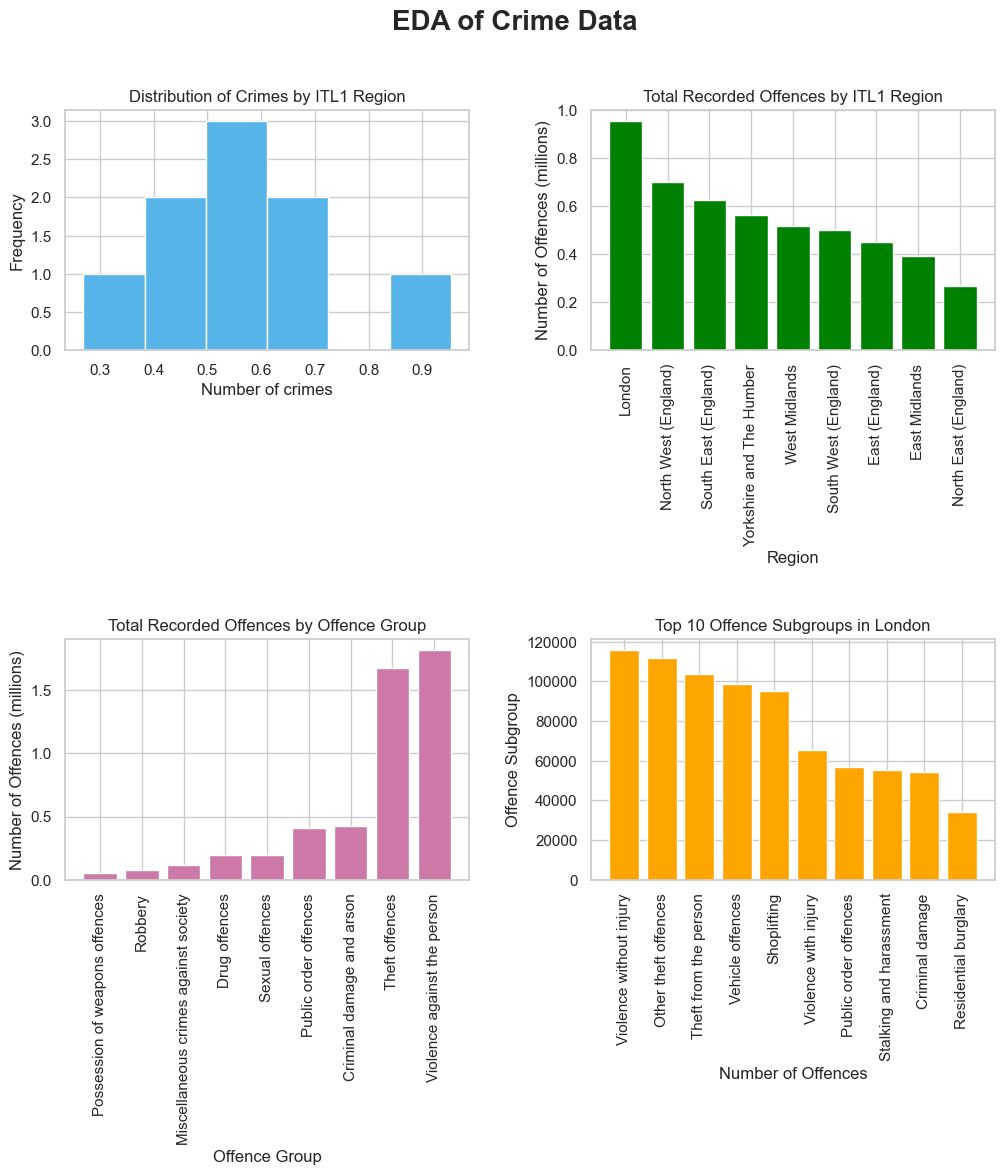

In [98]:
crime_by_region = (
    (df.groupby("ITL1 region")["Number of Offences"].sum()/1e6)
      .sort_values(ascending=False))

# Create 2x2 subplot layout

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("EDA of Crime Data", fontsize=20, fontweight="bold", y=0.98)

# Top-left: Crime Frequency
axes[0,0].hist(crime_by_region, bins=6, color="#56B4E9")

axes[0,0].set_xlabel("Number of crimes")
axes[0,0].set_ylabel("Frequency")
axes[0,0].set_title("Distribution of Crimes by ITL1 Region")


#Top Right
axes[0,1].bar(crime_by_region.index, crime_by_region.values, color="green")
axes[0,1].set_xlabel("Region")
axes[0,1].set_title("Total Recorded Offences by ITL1 Region")
axes[0,1].set_ylabel("Number of Offences (millions)")
axes[0,1].tick_params(axis="x", rotation=90)

#Bottom Left
crime_by_group = (
    (df.groupby("Offence Group")["Number of Offences"]
      .sum()/1e6)
      .sort_values(ascending=True)
)


crime_by_force = (
    df.groupby("Force Name")["Number of Offences"]
      .sum()
      .sort_values(ascending=True)
)

crime_by_force.head(10)

# Top Offence Groups
crime_by_subgroup = (
    df.groupby("Offence Subgroup")["Number of Offences"]
      .sum()
      .sort_values(ascending=True)
)

crime_by_subgroup.head(10)
df[
    ["Offence Group", "Offence Subgroup"]
].drop_duplicates().sort_values(
    ["Offence Group", "Offence Subgroup"]
).reset_index(drop=True)

axes[1,0].bar(crime_by_group.index, crime_by_group.values)
axes[1,0].set_title("Total Recorded Offences by Offence Group")
axes[1,0].set_xlabel("Offence Group")
axes[1,0].set_ylabel("Number of Offences (millions)")
axes[1,0].tick_params(axis="x", rotation=90)

# Bottom Right: London Deep Dive

london_subgroups = (
    df[df["ITL1 region"] == "London"]
    .groupby("Offence Subgroup")["Number of Offences"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

axes[1,1].bar(london_subgroups.index, london_subgroups.values,color="orange")
axes[1,1].set_title("Top 10 Offence Subgroups in London")
axes[1,1].set_xlabel("Number of Offences")
axes[1,1].set_ylabel("Offence Subgroup")
axes[1,1].tick_params(axis="x", rotation=90)

# Top Five Reported Offence Subgroups by ITL Region

top5_by_region = (
    df.groupby(
        ["ITL1 region", "Offence Subgroup"]
    )["Number of Offences"]
    .sum()
    .reset_index()
)

fig.subplots_adjust(hspace=1.2, wspace=0.3)


Explanation of crime data exploration graphs
1) The first chart highlights the range of number of crimes committed across ITL regions. We can see the data is broadly normally distributed and therefore doesn't need to be adjusted to factor in any crazy outliers.

2) The second chart illustrates, in descending order, the total number of recorded offences across England's nine ITL1 regions during the 2024/25 financial year. The 1 at the top of the y-axis is 1,000,000. We can see that London recorded the highest number of offences, and the North East of England the lowest. It should be noted the higher numbers may be due to a larger population in the area rather than higher crime rates.

3) The third chart shows the total number of recorded offences for each offence group across England during 2024/25. 
    The chart shows that Violence against the person was the most frequently recorded offence group, recording 1.8 million offences. This is closely followed by Theft Offences, with that offence group being recorded close to 1.7 million times.
    
    There is a notable drop after these first two categories, with Criminal Damage and Arson and Public Order Offences representing the next most common offence groups. At the lower end of the chart, Posession of Weapons Offences were among the least frequently recorded.
    
    These findings suggest that overall crime levels are driven primarily by offences relating to violence and theft.

4) The fourth chart shows the top 10 offences in London across 2024/25. The chart shows that Violence without injury was the most prominent crime across the city and residential bulgulary was the least.


## Key Findings from EDA of Crime Data

- The dataset contained no missing values or duplicate records.
- The dataset contained 22,464 records covering police recorded crime across England for 2024-2025.
- There were 39 police forces, covering 9 ITL1 regions and 33 ITL2 regions.
- Crime was classified into 9 offence groups, 25 offence subgroups and 144 offence descriptions.
- London recorded the highest number of offences of any ITL1 region.
- North East (England) recorded the lowest number of offences of any ITL1 region.
- Violence against the person was the largest offence group nationally.
- Violence Without Injury was the most frequently recorded subgroup.
- London had a distinctive crime profile when compared with other ITL1 regions; three of London's five most recorded offence subgroups were theft-related offences.

#### EDA of IMD data:


                                      ITL2      IMD Rank
14                     Inner London - East  11228.959387
33                           West Midlands  11697.638743
20                              Merseyside  12508.533400
32                             Tees Valley  13001.430588
29                         South Yorkshire  13145.600000
24  Northumberland, Durham and Tyne & Wear  13375.357995
11                      Greater Manchester  13461.296710
34                          West Yorkshire  14013.455840
4             Cornwall and Isles of Scilly  14240.795252
17                              Lancashire  14586.057143


C:\Users\jade_\AppData\Local\Temp\ipykernel_10376\2874249048.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='IMD Rank', y='ITL2', palette='Reds')


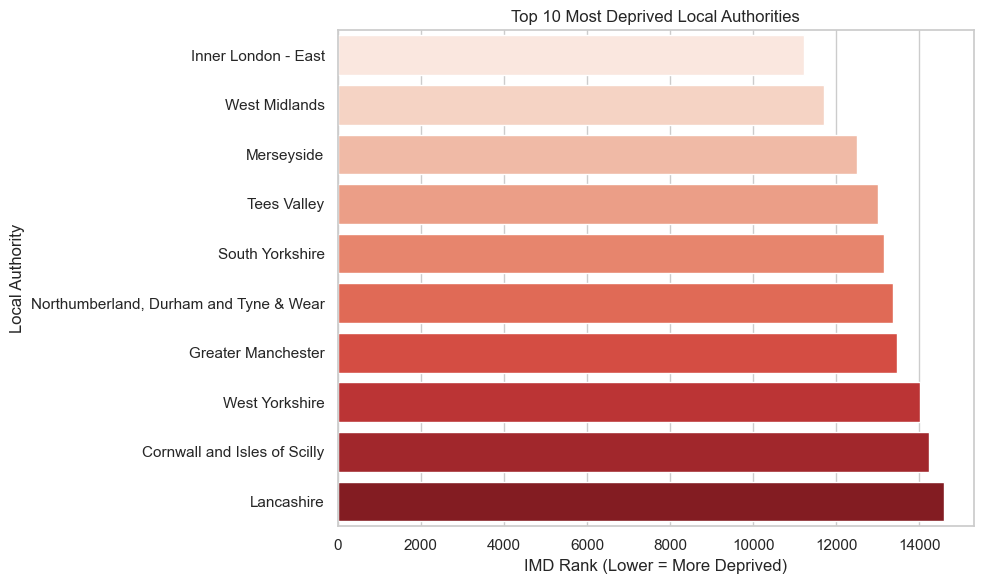

                                          ITL2      IMD Rank
1   Berkshire, Buckinghamshire and Oxfordshire  22988.432997
31                Surrey, East and West Sussex  21613.419908
10               Gloucestershire and Wiltshire  21101.028571
23                             North Yorkshire  21081.420000
3                                     Cheshire  21037.551839
26                        Outer London - South  20764.436856
0               Bedfordshire and Hertfordshire  20739.552212
35                             West of England  20216.789661
12                 Hampshire and Isle of Wight  20188.572705
2              Cambridgeshire and Peterborough  20027.490310


C:\Users\jade_\AppData\Local\Temp\ipykernel_10376\2874249048.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10, x='IMD Rank', y='ITL2', palette='Greens')


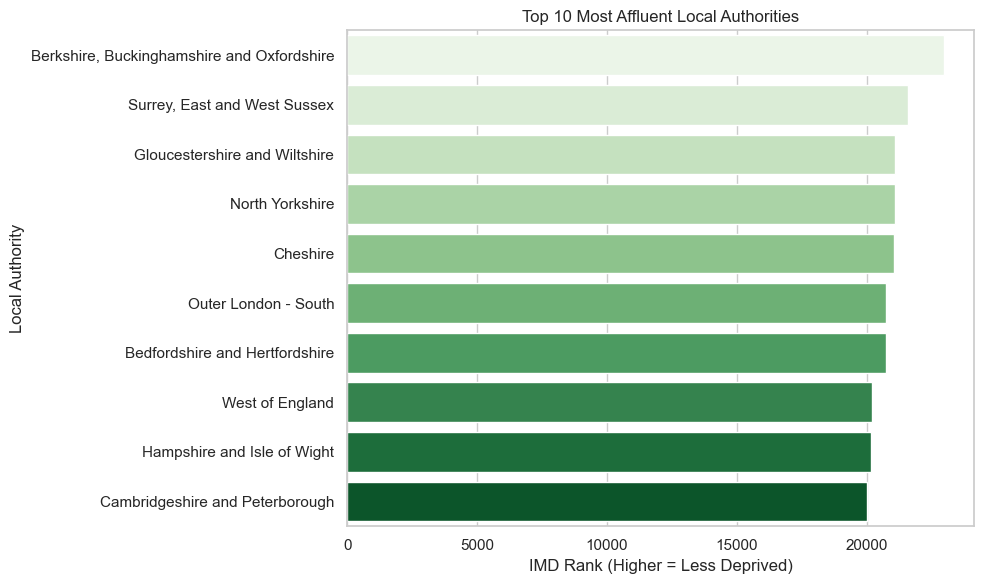

In [99]:
imd_df = pd.read_csv("clean_materials/clean_index_of_multiple_deprivation.csv")
imd_df['IMD Rank'].describe()
itl2_summary = imd_df.groupby('ITL2')['IMD Rank'].mean().reset_index()
itl2_summary = itl2_summary.sort_values('IMD Rank')
itl2_summary

okabeito = ['#CC79A7', '#56B4E9', '#009E73',\
           '#E69F00', '#0072B2', '#F0E442',\
           '#D55E00']
# sns.set_palette(okabeito)
# Top 10 most deprived (lowest IMD Rank)
top10 = itl2_summary.nsmallest(10, 'IMD Rank')
print(top10)

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x='IMD Rank', y='ITL2', palette='Reds')
plt.title('Top 10 Most Deprived Local Authorities')
plt.xlabel('IMD Rank (Lower = More Deprived)')
plt.ylabel('Local Authority')
plt.tight_layout()
plt.show()

bottom10 = itl2_summary.nlargest(10, 'IMD Rank')
print(bottom10)
plt.figure(figsize=(10,6))
sns.barplot(data=bottom10, x='IMD Rank', y='ITL2', palette='Greens')
plt.title('Top 10 Most Affluent Local Authorities')
plt.xlabel('IMD Rank (Higher = Less Deprived)')
plt.ylabel('Local Authority')
plt.tight_layout()
plt.show()




## Key Findings from EDA of IMD data

- Lower IMD Rank = more deprived.
- ITL2 regions show clear differences in deprivation.

The IMD 2019 data shows clear variation in deprivation levels across Local Authorities in England. Lower IMD Rank values indicate higher deprivation, while higher ranks indicate lower deprivation. By examining the extremes of the distribution, we can identify the areas facing the greatest and least socioeconomic challenges.

Top 3 Most Deprived Local Authorities
These ITL2s have the lowest IMD Rank values, meaning they experience the highest levels of deprivation:

- Inner London - East - IMD Rank 11,228
- West Midlands - IMD Rank 11,697
- Merseyside - IMD Rank 12,508


All three areas share the same IMD Rank, placing them among the most deprived communities in England. This suggests persistent challenges across multiple deprivation domains such as income, employment, health, and education.

Top 3 Most Affluent areas
These ITL2s have the highest IMD Rank values, meaning they are the least deprived:

- Berkshire, Buckinghamshire and Oxfordshire  - IMD Rank 22,988
- Surrey, East and West Sussex - IMD Rank 21,613
- Gloucestershire and Wiltshire - IMD Rank 21,101

These areas sit at the top end of the IMD distribution, reflecting stronger socioeconomic conditions and lower levels of deprivation across the board.

The contrast between the most and least deprived ITL2s is substantial.
The most deprived areas cluster at extremely low IMD ranks (around 11,000), while the least deprived ITLs reach ranks above 22,000. This highlights a significant inequality gap across England, with some communities facing concentrated disadvantage while others experience consistently favourable living conditions.

## Visualisations and in-depth statistical analysis

We have created a number of different visualisations to analyse and highlight the nuances of our data. We have explored all three datasets as part of our analysis, combined and sometimes alone to derive our key insights. Below is an overview of the graphs and you can find the key findings at the bottom of this section.

Accessibility: the Okabe-Ito colour pallete was used across all visualisations, to improve accessibility for a range of types of colourblindness.

Key visualisations:
- Crime vs IMD regions
- Crime vs Wellness indications (including life expectancy, life satisfaction and feeling safe after dark and an overall comparison of wellness indicators and crime)
- London Crime and Deprivation Analysis (ITL2 basis and borough deep dive)
- North, Midlands and South Analysis
- Deep Dive into the south

#### Overall Crime correlation to IMD regions

The aim of this graph is to show if there is a correlation between the IMD data 


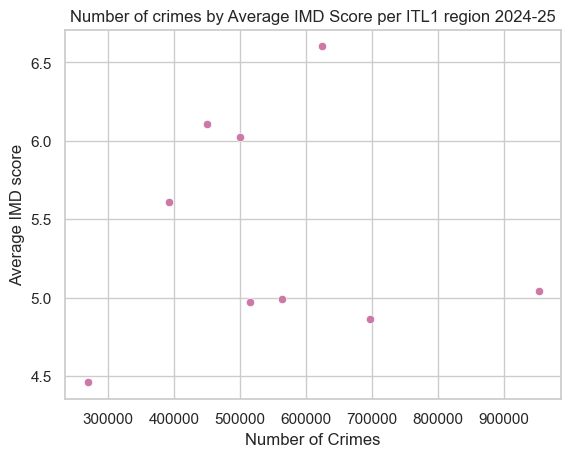

<Figure size 640x480 with 0 Axes>

In [100]:
crime_df = pd.read_csv("clean_materials/CLEANED-regional_forces_crime_data_2024-2025.csv")
imd_df = pd.read_csv("clean_materials/clean_index_of_multiple_deprivation.csv")


# Check to see if there are corresponding columns
# print(crime_df.columns) 
# print(imd_df.columns)

# print(crime_df.info())

crime_df.rename(columns={"ITL1 region": "ITL1", "ITL2 region": "ITL2"}, inplace=True) # The two excel files have different names for the columns so I'm cleaning these to check
# print(imd_df["ITL1"].tail(4))
# print(crime_df["ITL1"].tail(4))


crime_df.loc[crime_df["ITL1"] == "East Midlands", "ITL1"] = "East Midlands (England)" # Making sure the data is uniform in these specific columns
crime_df.loc[crime_df["ITL1"] == "West Midlands", "ITL1"] = "West Midlands (England)"

#ITL1 comparison

ITL1_grouped_crimes = crime_df.groupby("ITL1")["Number of Offences"].sum()
# print(ITL1_grouped_crimes)
number_of_crimes = crime_df.groupby("Offence Group")["Number of Offences"].sum()

avg_imd_by_ITL1 = imd_df.groupby("ITL1")["IMD Decile"].mean() # Finding the average mean for the ITL1 regions IMD scores
avg_imd_by_ITL2 = imd_df.groupby("ITL2")["IMD Decile"].mean() # Finding the average mean for the ITL2 regions IMD scores
avg_imd_rank_by_ITL2 = imd_df.groupby("ITL2")["IMD Rank"].mean()
IMD2_dict = avg_imd_by_ITL2.to_dict()
IMD_dict = avg_imd_by_ITL1.to_dict()
IMD2_rank_dict = avg_imd_rank_by_ITL2.to_dict()


crime_df["IMD_ITL1"] = crime_df["ITL1"].map(IMD_dict)

regional_summary = crime_df.groupby("ITL1").agg(
    total_offences = ("Number of Offences", "sum"),
    avg_imd_by_ITL1 =("IMD_ITL1", "mean"))


sns.scatterplot(x="total_offences", y="avg_imd_by_ITL1", data=regional_summary)
plt.xlabel("Number of Crimes")
plt.ylabel("Average IMD score")
plt.title("Number of crimes by Average IMD Score per ITL1 region 2024-25")

plt.show()

plt.tight_layout()


0        [West of England, North Somerset, Somerset and...
1        [West of England, North Somerset, Somerset and...
2        [West of England, North Somerset, Somerset and...
3        [West of England, North Somerset, Somerset and...
4        [West of England, North Somerset, Somerset and...
                               ...                        
22459                      [Gloucestershire and Wiltshire]
22460                      [Gloucestershire and Wiltshire]
22461                      [Gloucestershire and Wiltshire]
22462                      [Gloucestershire and Wiltshire]
22463                      [Gloucestershire and Wiltshire]
Name: ITL2, Length: 22464, dtype: object
   Unnamed: 0 Financial Year  Financial Quarter         Force Name  \
0           0        2024/25                  1  Avon and Somerset   
0           0        2024/25                  1  Avon and Somerset   
1           1        2024/25                  1  Avon and Somerset   

                             

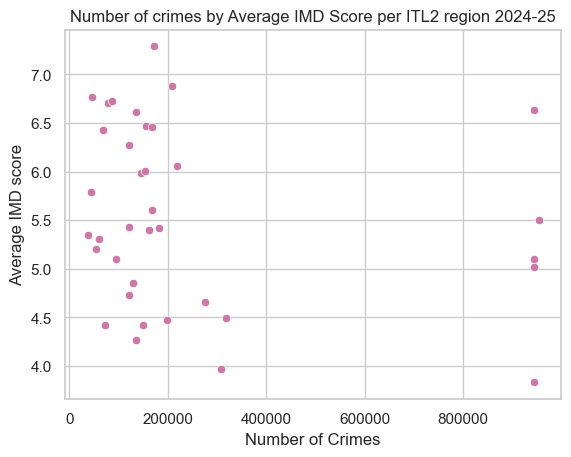

In [101]:

#ITL2 scatter graph
crime_df["ITL2"] = crime_df["ITL2"].apply(lambda x: x.split(";")) # This converts the values into a list so that I can find all of their IMD ratings
print(crime_df["ITL2"])
individual_ITL2 = crime_df.explode("ITL2")
print(individual_ITL2.head(3))
print(crime_df.head(3))
avg_imd_by_ITL2 = imd_df.groupby("ITL2")["IMD Decile"].mean()
IMD2_dict = avg_imd_by_ITL2.to_dict()
IMD2_rank_dict
individual_ITL2["IMD_ITL2"] = individual_ITL2["ITL2"].map(IMD2_dict)
individual_ITL2["IMD_rank_ITL2"] = individual_ITL2["ITL2"].map(IMD2_rank_dict)



regional_summary = individual_ITL2.groupby("ITL2").agg( # Now I will find the average IMD score per ITL2 region
    total_offences = ("Number of Offences", "sum"),
    avg_imd_by_ITL2 =("IMD_ITL2", "mean"),
    avg_imd_rank_by_ITL2 = ("IMD_rank_ITL2", "mean")
    )
# print(regional_summary.head(3)) # testing to see if it has created a good table
regional_summary.to_csv("machine_learning/machine_learning.csv")

sns.scatterplot(x="total_offences", y="avg_imd_by_ITL2",  data=regional_summary)
plt.xlabel("Number of Crimes")
plt.ylabel("Average IMD score")
plt.title("Number of crimes by Average IMD Score per ITL2 region 2024-25")
plt.show()

#### Wellness Data X Crime Data


                ITL1 region  Number of Offences                    Region
0            East (England)              450512           East of England
1             East Midlands              392047             East Midlands
2                    London              953103                    London
3      North East (England)              269244                North East
4      North West (England)              698039                North West
5      South East (England)              624439                South East
6      South West (England)              500612                South West
7             West Midlands              515180             West Midlands
8  Yorkshire and The Humber              563303  Yorkshire and The Humber


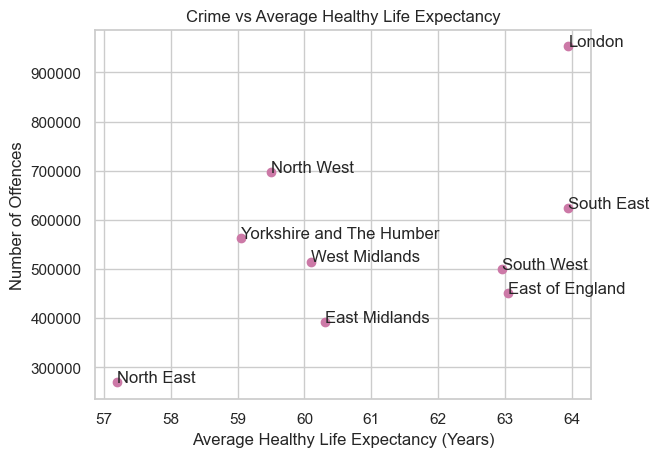

Average life expectancy correlation: 0.543


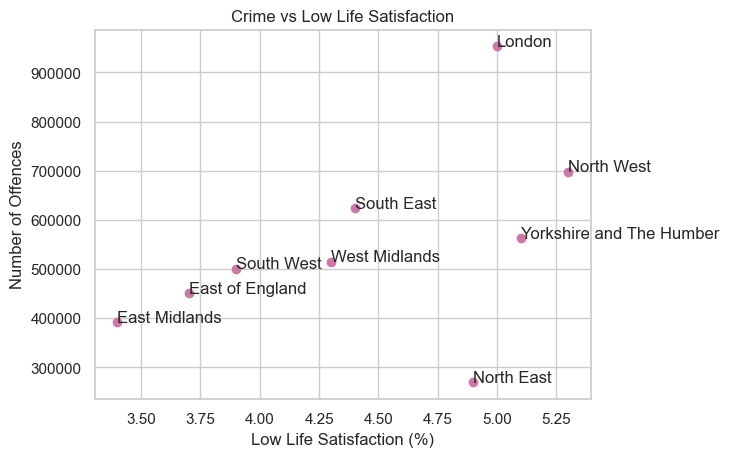

Low life satisfaction correlation: 0.472


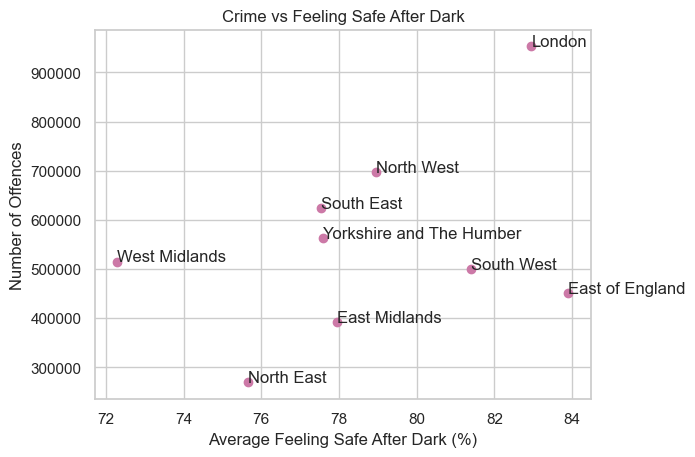

Feeling safe after dark correlation: 0.385


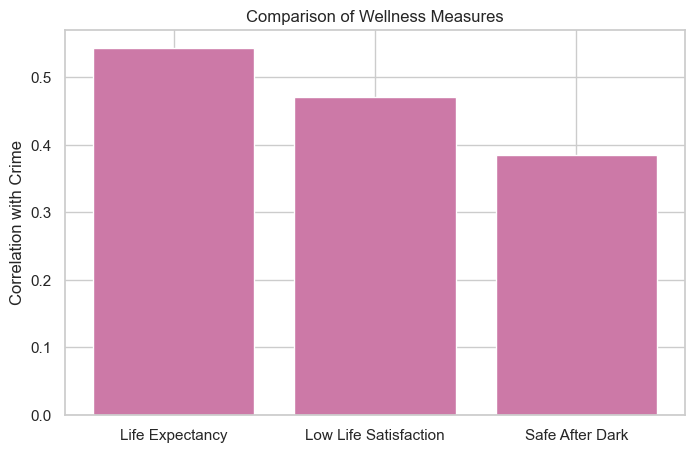

In [102]:
crime_df = pd.read_csv("clean_materials/CLEANED-regional_forces_crime_data_2024-2025.csv")

crime_by_region_df = (
    crime_df
    .groupby("ITL1 region")["Number of Offences"]
    .sum()
    .reset_index()
)

crime_by_region_df["Region"] = (
    crime_by_region_df["ITL1 region"]
    .str.replace(" \\(England\\)", "", regex=True)
    .replace({"East": "East of England"})
)

print(crime_by_region_df)

# Life Expectancy

life_expectancy_df = pd.read_excel(
    "clean_materials/CLEANED-Wellness_Data.xlsx",
    sheet_name=5
)


crime_life_expectancy_df = pd.merge(
    crime_by_region_df,
    life_expectancy_df,
    on="Region",
    how="inner"
)

crime_life_expectancy_df["Average_Life_Expectancy"] = (
    crime_life_expectancy_df["Male_Life_Expectancy_Years"] +
    crime_life_expectancy_df["Female_Life_Expectancy_Years"]
) / 2




plt.scatter(
    crime_life_expectancy_df["Average_Life_Expectancy"],
    crime_life_expectancy_df["Number of Offences"]
)

plt.xlabel("Average Healthy Life Expectancy (Years)")
plt.ylabel("Number of Offences")
plt.title("Crime vs Average Healthy Life Expectancy")

for _, row in crime_life_expectancy_df.iterrows():
    plt.annotate(
        row["Region"],
        (
            row["Average_Life_Expectancy"],
            row["Number of Offences"]
        )
    )

plt.show()

life_expectancy_corr = crime_life_expectancy_df[
    "Average_Life_Expectancy"
].corr(
    crime_life_expectancy_df["Number of Offences"]
)

print(f"Average life expectancy correlation: {life_expectancy_corr:.3f}")

# Low Life Satisfaction

life_satisfaction_df = pd.read_excel(
    "clean_materials/CLEANED-Wellness_Data.xlsx",
    sheet_name=0
)

crime_life_satisfaction_df = pd.merge(
    crime_by_region_df,
    life_satisfaction_df,
    on="Region",
    how="inner"
)

plt.scatter(
    crime_life_satisfaction_df["Low_Life_Satisfaction_Percentage"],
    crime_life_satisfaction_df["Number of Offences"]
)

plt.xlabel("Low Life Satisfaction (%)")
plt.ylabel("Number of Offences")
plt.title("Crime vs Low Life Satisfaction")

for _, row in crime_life_satisfaction_df.iterrows():
    plt.annotate(
        row["Region"],
        (
            row["Low_Life_Satisfaction_Percentage"],
            row["Number of Offences"]
        )
    )

plt.show()

life_satisfaction_corr = crime_life_satisfaction_df[
    "Low_Life_Satisfaction_Percentage"
].corr(
    crime_life_satisfaction_df["Number of Offences"]
)

print(f"Low life satisfaction correlation: {life_satisfaction_corr:.3f}")


# Feeling Safe After Dark

safe_after_dark_df = pd.read_excel(
    "clean_materials/CLEANED-Wellness_Data.xlsx",
    sheet_name=13
)

safe_after_dark_df["Average_Safe_After_Dark"] = (
    safe_after_dark_df["Males_Who_Feel_Safe_Walking_Local_Area_Alone_After_Dark_Percentage"] +
    safe_after_dark_df["Females_Who_Feel_Safe_Walking_Local_Area_Alone_After_Dark_Percentage"]
) / 2

crime_safe_after_dark_df = pd.merge(
    crime_by_region_df,
    safe_after_dark_df,
    on="Region",
    how="inner"
)

plt.scatter(
    crime_safe_after_dark_df["Average_Safe_After_Dark"],
    crime_safe_after_dark_df["Number of Offences"]
)

plt.xlabel("Average Feeling Safe After Dark (%)")
plt.ylabel("Number of Offences")
plt.title("Crime vs Feeling Safe After Dark")

for _, row in crime_safe_after_dark_df.iterrows():
    plt.annotate(
        row["Region"], 
        (
            row["Average_Safe_After_Dark"],
            row["Number of Offences"]
        )
    )


plt.show()

safe_after_dark_corr = crime_safe_after_dark_df[
    "Average_Safe_After_Dark"
].corr(
    crime_safe_after_dark_df["Number of Offences"]
)

print(f"Feeling safe after dark correlation: {safe_after_dark_corr:.3f}")

# Correlation Comparison

measures = [
    "Life Expectancy",
    "Low Life Satisfaction",
    "Safe After Dark"
]

correlations = [
    life_expectancy_corr,
    life_satisfaction_corr,
    safe_after_dark_corr
]


plt.figure(figsize=(8, 5))

plt.bar(
    measures,
    correlations
)

plt.ylabel("Correlation with Crime")
plt.title("Comparison of Wellness Measures")

plt.show()

#### London Crime & Deprivation Analysis 

I found during exploratory data analysis that not only did London report the most offences, but it also had a distinctive crime profile. Of the five most recorded offence subgroups, three were theft related offences - other theft offences, theft from the person and shoplifting. This suggested that theft-related crime may play a particularly important role in explaining crime patterns within London and motivated further investigation alongside deprivation data.

How to interpret the IMD numbers: 

For **IMD Rank, the smaller the number the more deprived an area is**. Based on the data above, **Inner London East is the most deprived** ITL2 region in London, and **Outer London - South is the least deprived** ITL2 region in London. 

The **IMD Decile** categorises more broadly, deciles range from 1-10. **Decile 1** = Most deprived 10% of areas in England and **Decile 10** = Least deprived 10% of areas in England.



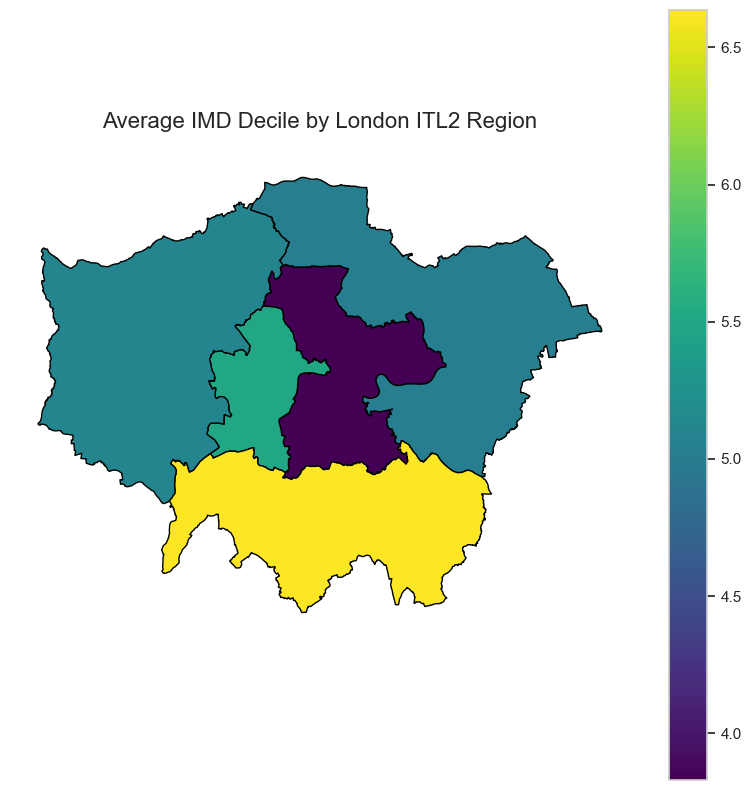

In [103]:
crime_df = pd.read_csv("clean_materials/CLEANED-regional_forces_crime_data_2024-2025.csv")

imd_df = pd.read_csv("clean_materials/clean_index_of_multiple_deprivation.csv")

imd_map = pd.read_csv(
    "clean_materials/_2025_index_of_multiple_deprivation.csv",
)

london_imd = imd_df[
    imd_df["ITL1"] == "London"
]

london_imd["ITL2"].value_counts() # Before visualising deprivation, the number of observations in each ITL2 region was examined

london_imd_summary = ( # To compare deprivation across London's five ITL2 regions, average IMD rank and IMD decile values were calculated. # To understand deprivation at a broader level, the average IMD decile was calculated for each of London's five ITL2 regions.
    london_imd
    .groupby("ITL2")
    .agg({
        "IMD Rank": "mean",
        "IMD Decile": "mean"
    })
    .reset_index()
)

london_imd_summary 

imd_map_clean = imd_map.rename(columns={ # The IMD dataset and boundary files use different column names for the LSOA identifier (a geographic area used primarily by the Office for National Statistics). The relevant columns were renamed to create a join key and make analysis simpler
    "LSOA code (2021)": "lsoa21cd",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "IMD Rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA": "IMD Decile"
})


imd_map_clean["ITL2"] = imd_df["ITL2"]

shp_files = [
    f for f in os.listdir("LB_shp")
    if f.endswith(".shp")
]

boroughs = []

for shp in shp_files:
    gdf = gpd.read_file(f"LB_shp/{shp}")
    boroughs.append(gdf)

london_boundaries = pd.concat(
    boroughs,
    ignore_index=True
)

london_map = london_boundaries.merge(
    imd_map_clean,
    on="lsoa21cd",
    how="left"
)

itl2_map = ( # To provide an overview of deprivation across London, the average IMD decile was calculated for each of the five ITL2 regions. This allows deprivation patterns to be compared regionally before examining neighbourhood-level variation:
    london_map
    .dissolve(
        by="ITL2",
        aggfunc={
            "IMD Rank": "mean",
            "IMD Decile": "mean"
        }
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 10))

itl2_map.plot(
    column="IMD Decile",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=1,
    ax=ax
)

ax.set_title(
    "Average IMD Decile by London ITL2 Region",
    fontsize=16,
    pad=20
)

ax.axis("off")

plt.show()



#### Visualising Deprivation Data Across London in more detail

Although direct comparison between crime and deprivation was not possible, the ITL2 analysis suggested that regional averages may hide important local variation. To investigate this further, deprivation was examined at LSOA level.

At ITL2 level, London appears to exhibit a straightforward deprivation pattern. Inner London - East (dark purple) has the lowest average IMD decile and is therefore the most deprived region on average, while Outer London - South (yellow) has the highest average IMD decile and is the least deprived. However, these averages may mask variation within each region.

To better understand how deprivation varies across London, a geographic visualisation was created. Choropleth maps are particularly useful for displaying regional differences because they allow patterns to be viewed spatially rather than as a simple ranking.

A choropleth map was preferred to a traditional bar chart because IMD Rank is an inverse measure of deprivation, where lower values indicate greater deprivation. While a bar chart could still be used, it may be less intuitive for readers, as taller bars would represent areas with lower levels of deprivation. A map provides a clearer visual representation of how deprivation is distributed across London.

With these findings it is clear that there is significant variation in IMDs across London and to get a more accurate picture of data. The choropleth map highlights substantial variation in deprivation across London. Areas with lower IMD deciles (shown in darker colours) are concentrated in several parts of Inner London, although deprivation is present throughout the capital. Areas with higher IMD deciles (shown in lighter colours) are more common in parts of Outer London. The map demonstrates that deprivation is not evenly distributed across London and varies considerably between neighbourhoods.

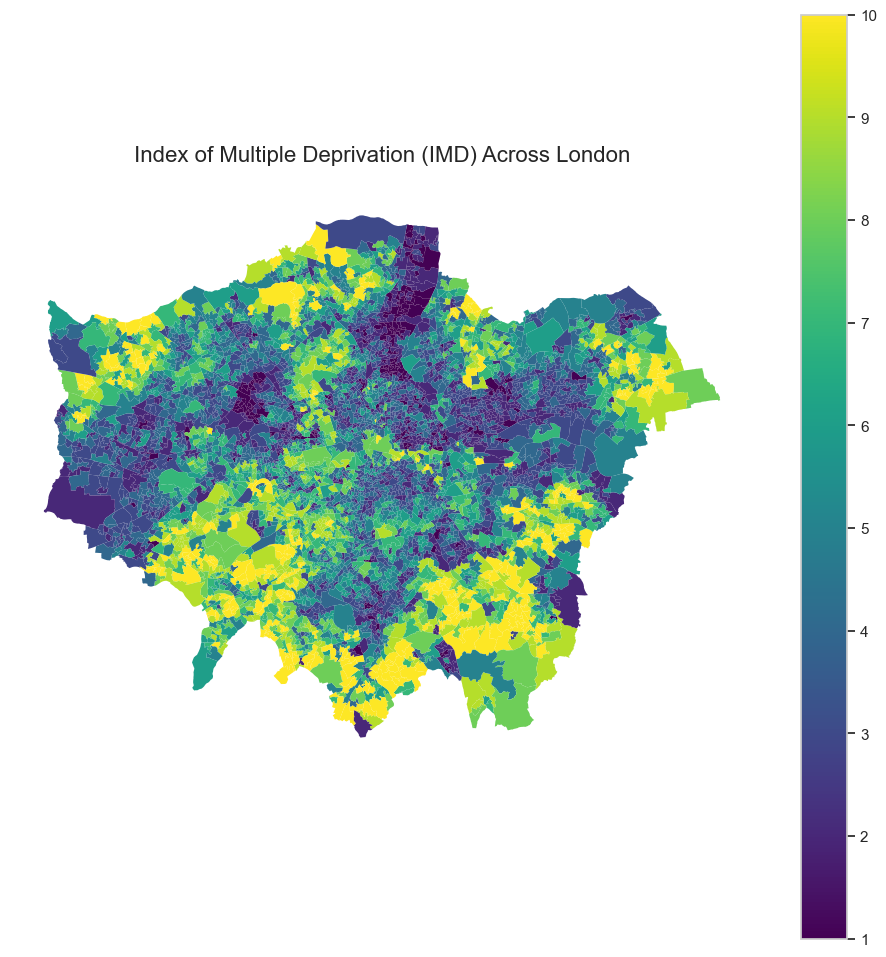

In [104]:
imd_map_clean = imd_map.rename(columns={
    "LSOA code (2021)": "lsoa21cd",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "IMD Rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA": "IMD Decile"
})

london_map = london_boundaries.merge( #The deprivation data was merged with the London boundary data using the LSOA code, creating a dataset suitable for geographic visualisation.
    imd_map_clean,
    on="lsoa21cd",
    how="left"
)

london_map = london_boundaries.merge(
    imd_map_clean,
    on="lsoa21cd",
    how="left"
)

#Chlorepath Map

fig, ax = plt.subplots(figsize=(12, 12))

london_map.plot(
    column="IMD Decile",
    cmap="viridis",
    legend=True,
    linewidth=0,
    ax=ax
)

ax.set_title(
    "Index of Multiple Deprivation (IMD) Across London",
    fontsize=16,
    pad=20
)

ax.axis("off")

plt.show()

## North, Midlands and South Data Visualisation

Creation of two bar plots - the first will visualise the average IMD rank for the North, Midlands and South of England, whilst the second will visualise the total crime rates, per offense group, by geographic region (North, Midlands and South of England).

 - North will encompass ITL1: 'North East', 'North West', 'Yorkshire and the Humber'
 - Midlands will encompass ITL1: 'East Midlands', 'West Midlands'
 - South will encompass ITL1: 'East', 'London', 'South East', 'South West'

Please note: data checks have been commented out to save space on the output, please delete the # if you would also like to inspect the data this frequently

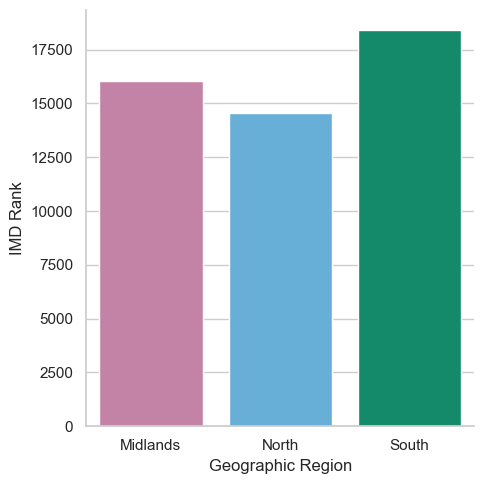

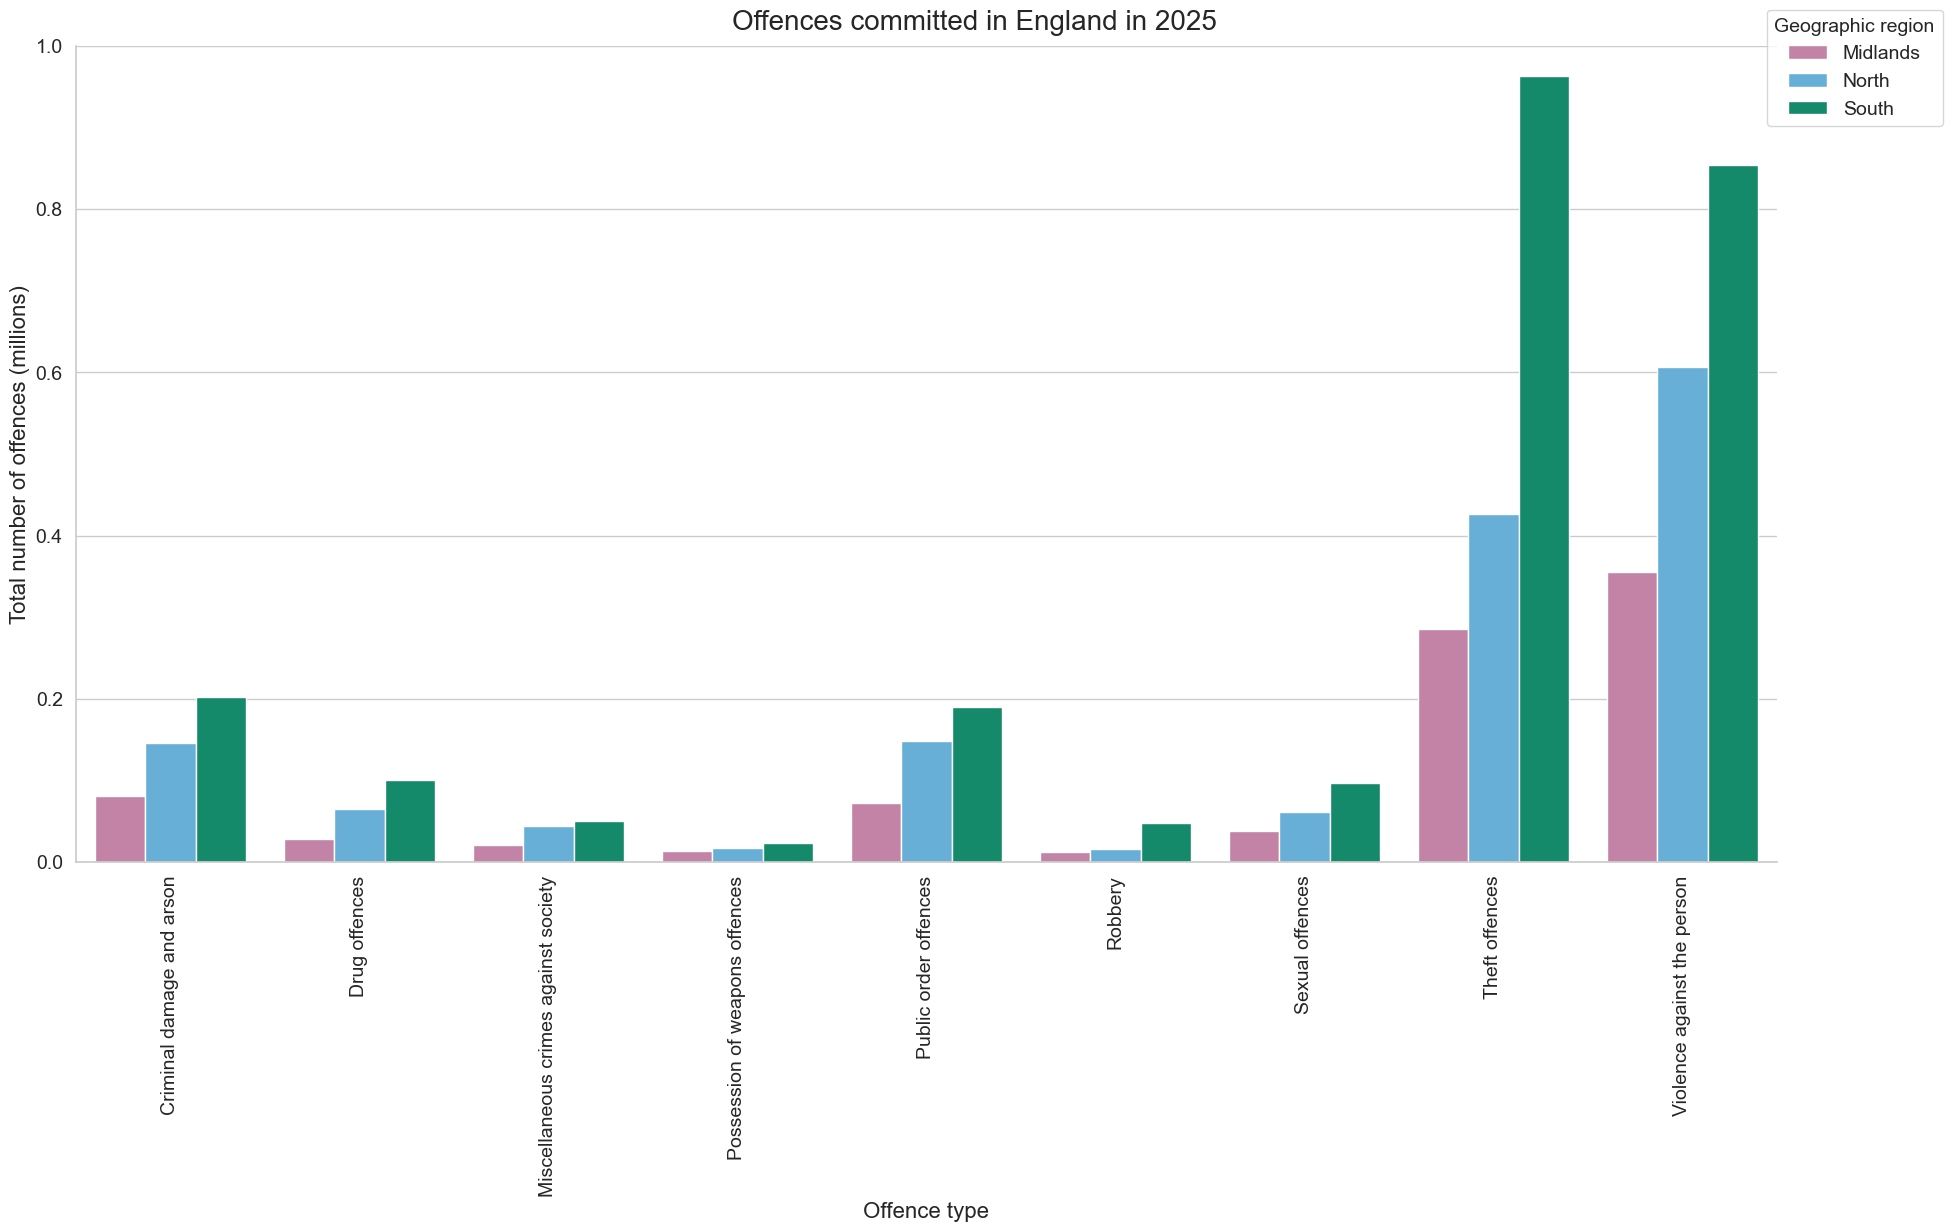

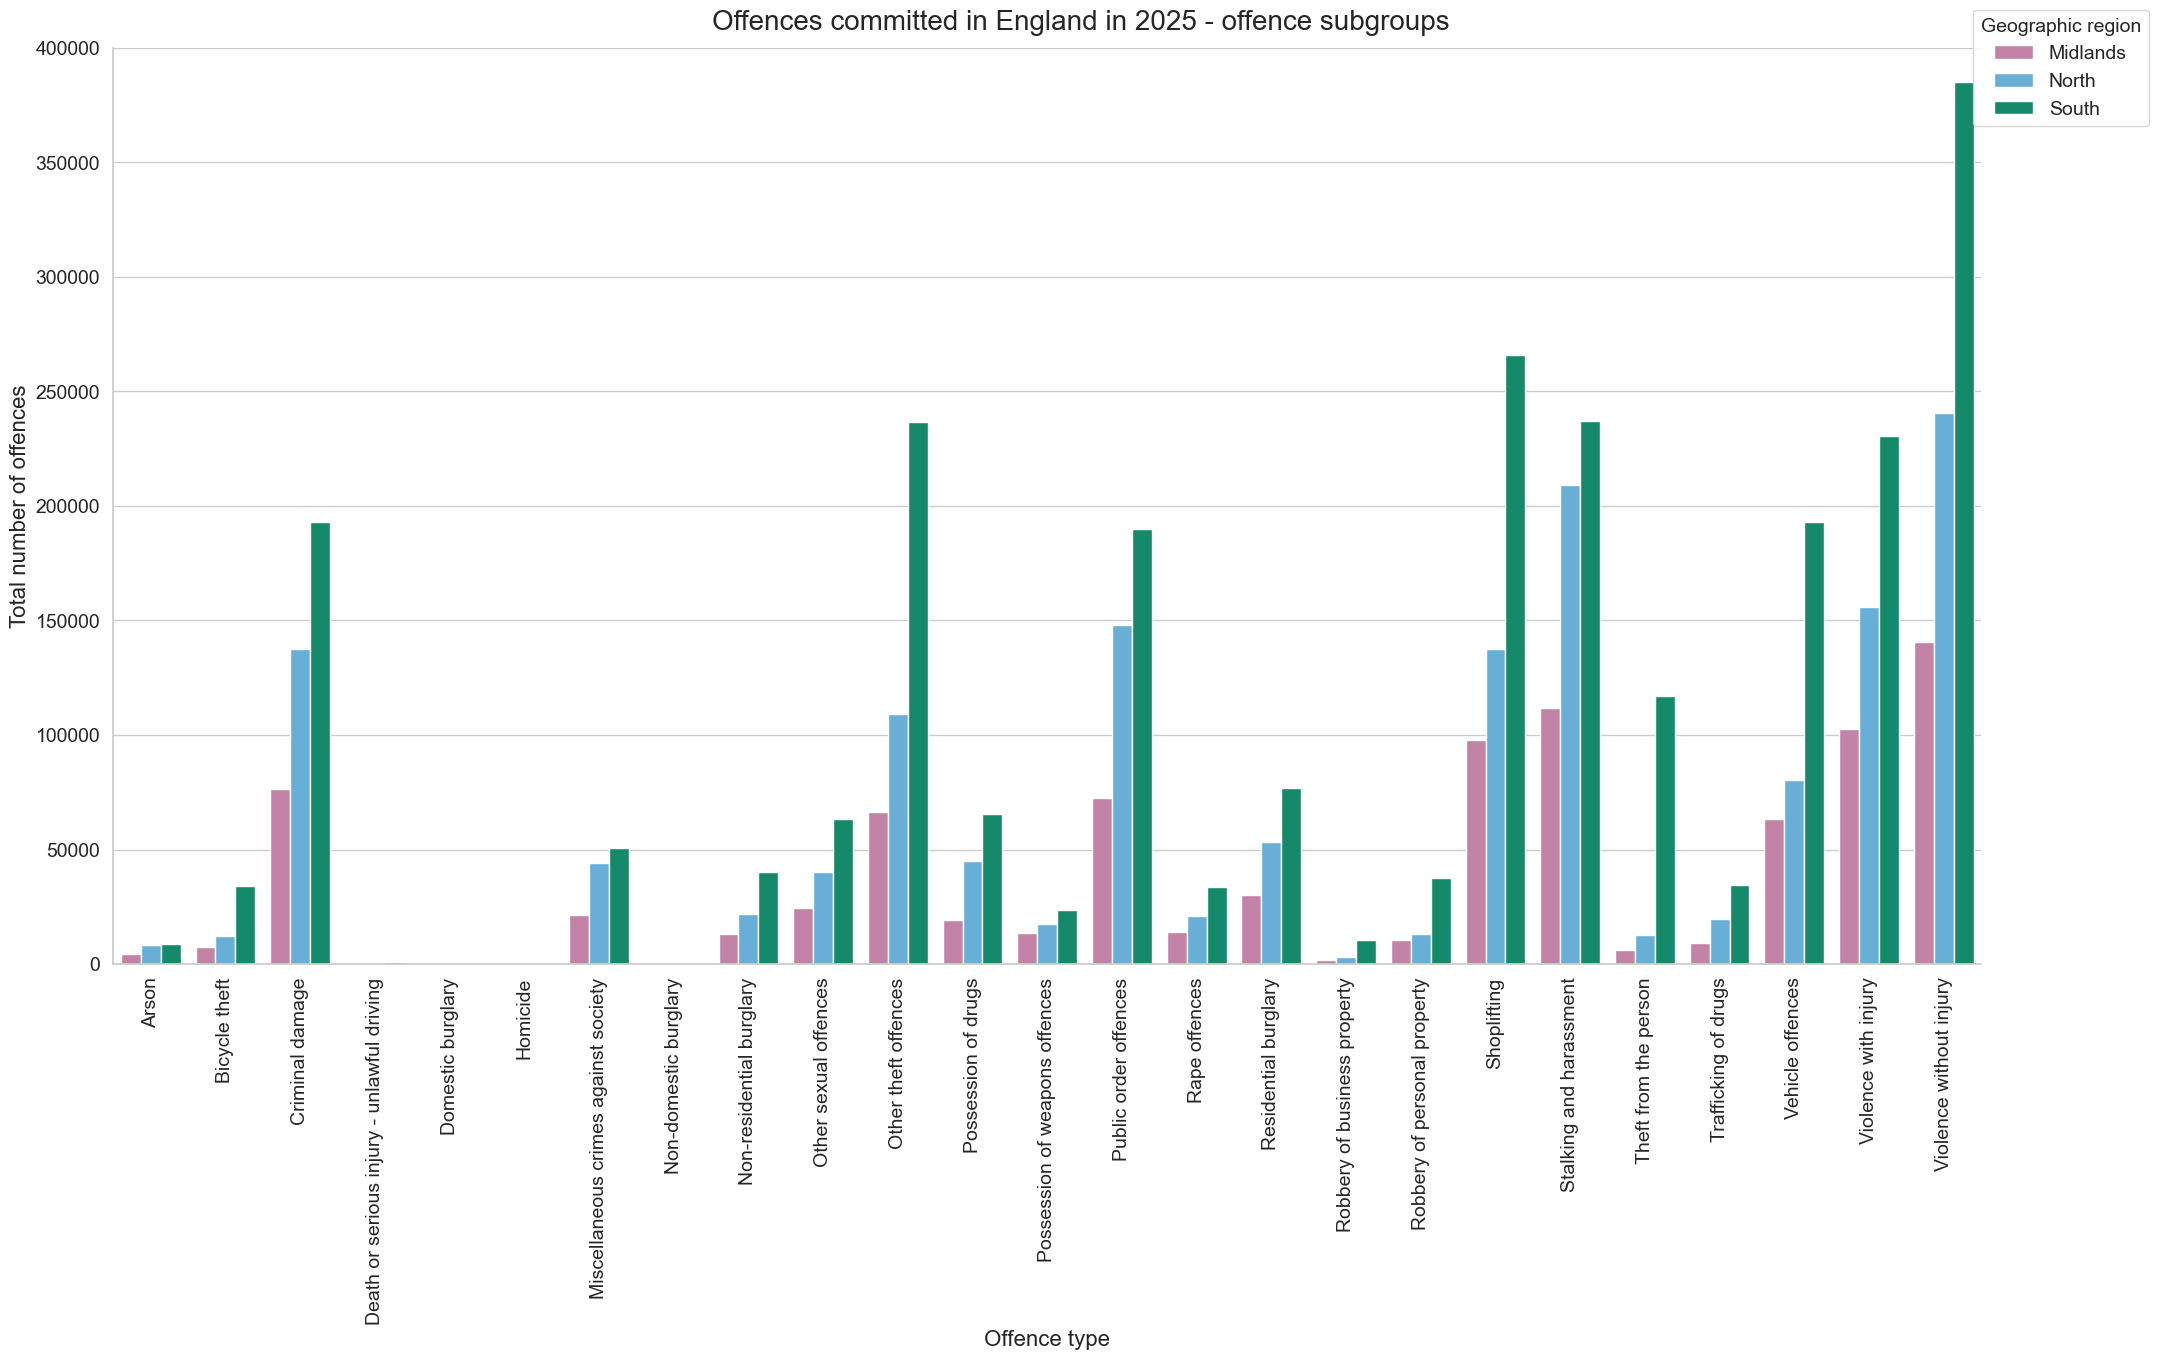

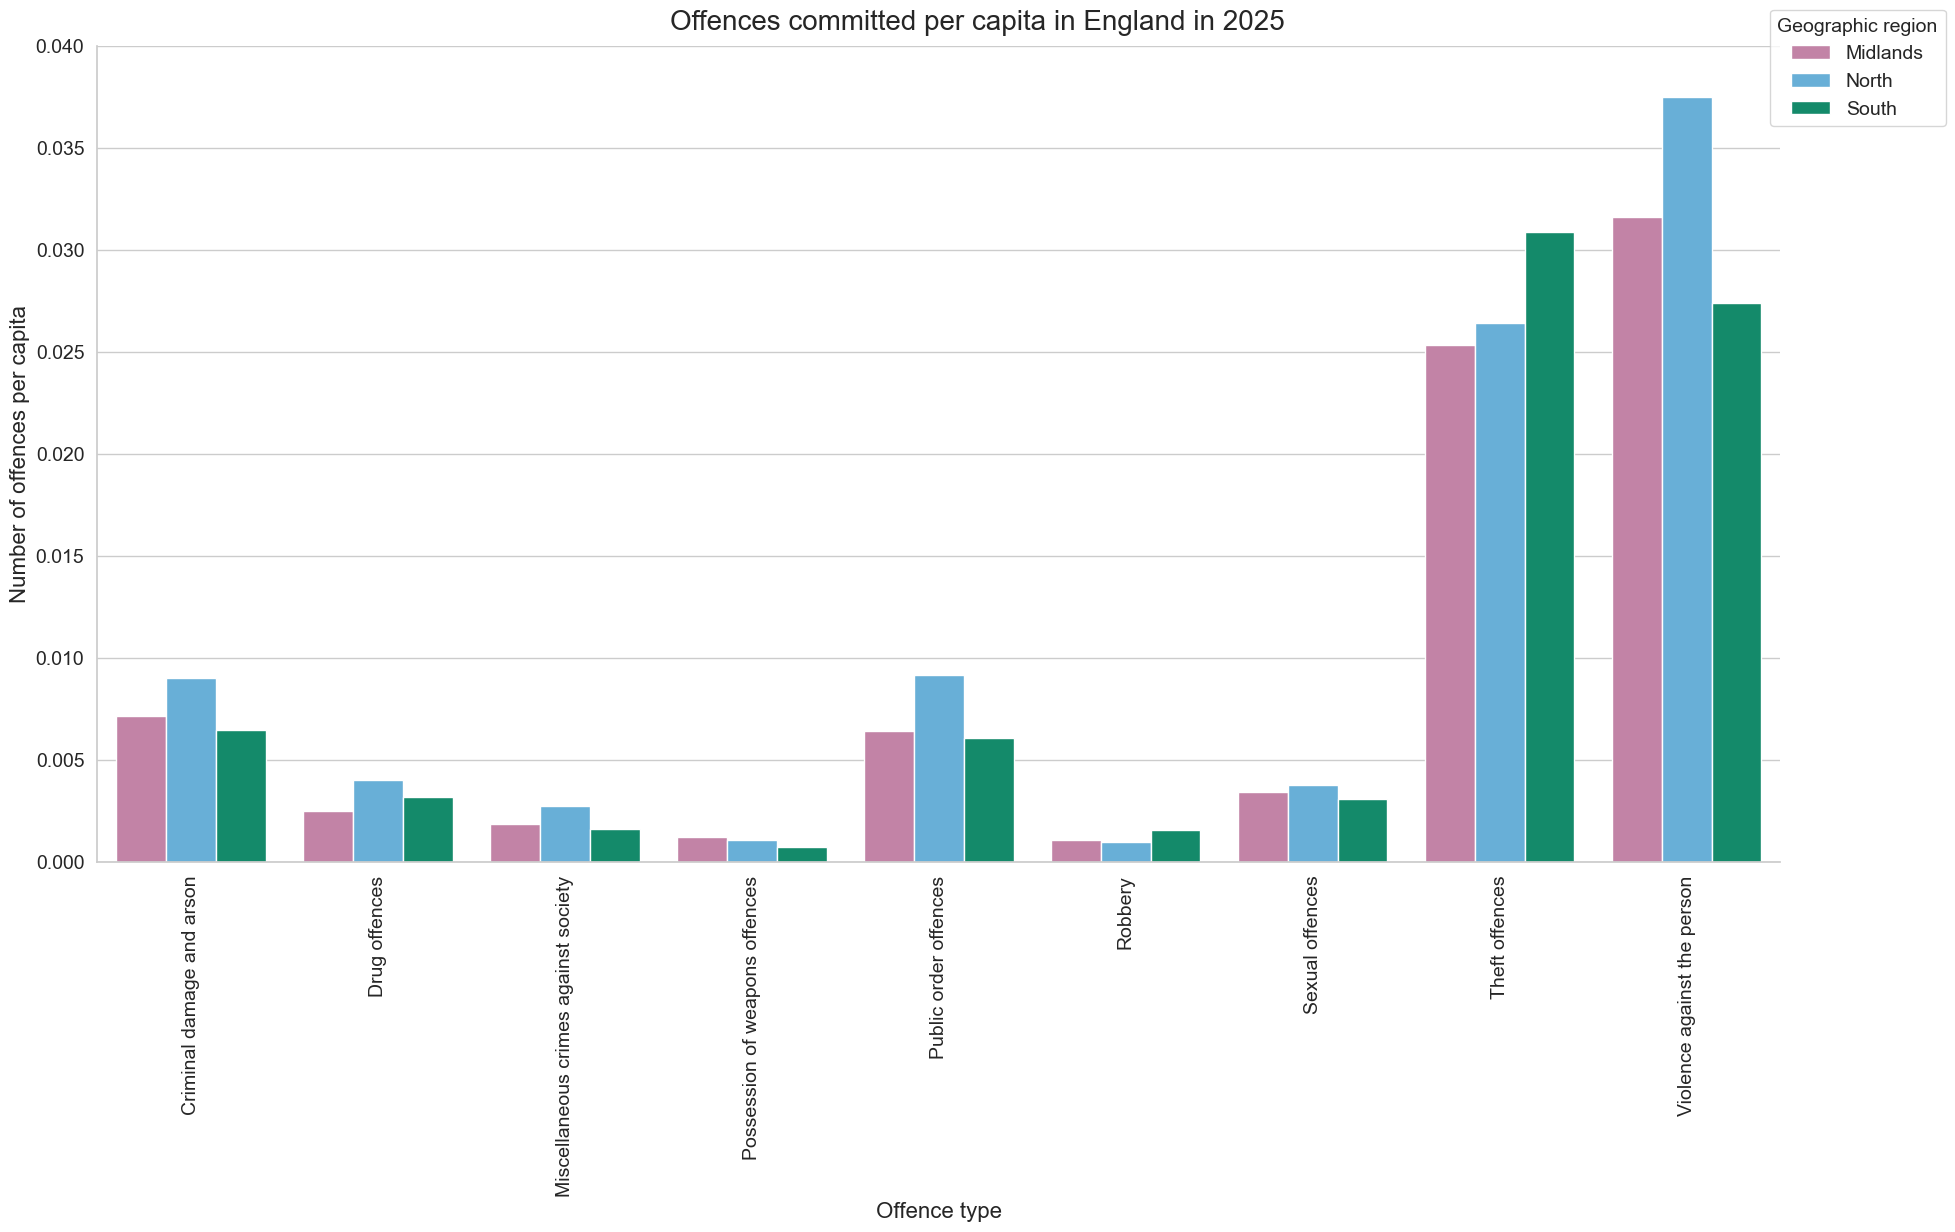

In [106]:
# AVERAGE IMD RANKING, BY REGION (NORTH, MIDLANDS, SOUTH) - BARPLOT
imd_df = pd.read_csv('clean_materials/clean_index_of_multiple_deprivation.csv')

# Visually checking the head of the data
# display(imd_df.head(2))

# Renaming ITL1 regions and grouping into North, Midlands or South
imd_df_v2 = imd_df.replace({'North East (England)': 'North', 'North West (England)': 'North',\
                                'Yorkshire and The Humber': 'North', 'East Midlands (England)': 'Midlands',\
                               'West Midlands (England)': 'Midlands', 'East (England)': 'South', 'London':'South',\
                               'South East (England)':'South', 'South West (England)': 'South'}, inplace=True)
imd_df_v2.rename(columns={'ITL1': 'Geographic Region'}, inplace=True)

# Check changes have been made correctly
# display(imd_df_v2.head(2))

# Average IMD ranking for each geographic region
imd_s = imd_df_v2.groupby(['Geographic Region'])['IMD Rank'].mean()
# display(imd_s.head(20))

# To note: the .groupby() function has changed the df to a series
# Need to convert back to a df, to then use the seaborn .catplot() function
# print(type(imd_s))
imd_df_v3 = imd_s.reset_index()
# print(type(imd_df_v3))

# display(imd_df_v3.head(5))

# One of the best colour palettes for colour blindness is 'okabeito'

okabeito = ['#CC79A7', '#56B4E9', '#009E73',\
           '#E69F00', '#0072B2', '#F0E442',\
           '#D55E00']
sns.set_palette(okabeito)



plt.show()

# Creating the graph
imd_graph = sns.catplot(
                data=imd_df_v3, kind='bar',
                x='Geographic Region', y='IMD Rank',
                hue='Geographic Region',
                alpha=1, 
                height=5, aspect=1
)

plt.show()


# CRIME RATES, BY OFFENCE GROUP, BY REGION (NORTH, MIDLANDS, SOUTH OF ENGLAND) - BARPLOT
crime_df = pd.read_csv('clean_materials/CLEANED-regional_forces_crime_data_2024-2025.csv')

# Visually checking the head of the data
# display(crime_df.head(2))

# Renaming ITL1 regions and grouping into North, Midlands or South
crime_df_v2 = crime_df.replace({'North East (England)': 'North', 'North West (England)': 'North',\
                                'Yorkshire and The Humber': 'North', 'East Midlands': 'Midlands',\
                               'West Midlands': 'Midlands', 'East (England)': 'South', 'London':'South',\
                               'South East (England)':'South', 'South West (England)': 'South'}, inplace=True)
crime_df_v2.rename(columns={'ITL1 region': 'Geographic Region'}, inplace=True)

# Check changes have been made correctly
# display(crime_df_v2.head(2))

# Total offences by geographic region
# Preparing/grouping the dataset, as required for the following graph
# NUMBER OF OFFENCES IN MILLIONS
crime_s = crime_df_v2.groupby(['Geographic Region', 'Offence Group'])['Number of Offences'].sum()/1e6
# display(crime_s.head(20))

# Descriptive statistics for the number of offenses in England
# display(crime_s.describe())

# To note: the .groupby() function has changed the df to a series
# Need to convert back to a df, to then use the seaborn .catplot() function
# print(type(crime_s))
crime_df_v3 = crime_s.reset_index()
# print(type(crime_df_v3))
crime_df_v3.rename(columns={'Number of Offences': 'Number of Offences (millions)'}, inplace=True)
# display(crime_df_v3.head(10))

#Creating the graph
sns.set_theme(style='whitegrid')

sns.set_palette(okabeito)

crime_graph = sns.catplot(
                data=crime_df_v3, kind='bar',
                x='Offence Group', y='Number of Offences (millions)',
                hue='Geographic Region', alpha=1, 
                height=9, aspect=2
)

crime_graph.fig.suptitle('Offences committed in England in 2025', y=1.02, fontsize=20)
crime_graph.set_xlabels('Offence type', fontsize=16)
crime_graph.set_ylabels('Total number of offences (millions)', fontsize=16, x=-1.05)
crime_graph.set_xticklabels(rotation=90, fontsize=14)
crime_graph.set_yticklabels(fontsize=14)
crime_graph.set(ylim=(0, 1))
crime_graph._legend.remove()
crime_graph.fig.legend(title='Geographic region', title_fontsize=14, fontsize=14)

plt.show()
# plt.savefig('Total offences committed in England in 2025 (North, South, Midlands)')


# CRIME RATES, BY OFFENCE SUB-GROUP, BY REGION (NORTH, MIDLANDS, SOUTH OF ENGLAND) - BARPLOT

# Total offences by geographic region
# Preparing/grouping the dataset, as required for the following graph
crime_s2 = crime_df_v2.groupby(['Geographic Region', 'Offence Subgroup'])['Number of Offences'].sum()
# display(crime_s2.head(20))

# Descriptive statistics for the number of offenses in England
# display(crime_s2.describe())

# To note: the .groupby() function has changed the df to a series
# Need to convert back to a df, to then use the seaborn .catplot() function
# print(type(crime_s2))
crime_df_v5 = crime_s2.reset_index()
# print(type(crime_df_v5))
#crime_df_v3.rename(columns={'Number of Offences': 'Number of Offences (millions)'}, inplace=True)
# display(crime_df_v5.head(50))

#Creating the graph
sns.set_theme(style='whitegrid')
sns.set_palette(okabeito)

crime_graph = sns.catplot(
                data=crime_df_v5, kind='bar',
                x='Offence Subgroup', y='Number of Offences',
                hue='Geographic Region', alpha=1, 
                height=10, aspect=2
)

crime_graph.fig.suptitle('Offences committed in England in 2025 - offence subgroups', y=1.02, fontsize=20)
crime_graph.set_xlabels('Offence type', fontsize=16)
crime_graph.set_ylabels('Total number of offences', fontsize=16, x=-1.05)
crime_graph.set_xticklabels(rotation=90, fontsize=14)
crime_graph.set_yticklabels(fontsize=14)
crime_graph.set(ylim=(0, 400000))
crime_graph._legend.remove()
crime_graph.fig.legend(title='Geographic region', title_fontsize=14, fontsize=14)

plt.show()
# plt.savefig('Total offences committed in England in 2025 (North, South, Midlands)subgroups')


# PER CAPITA CRIME RATES, BY OFFENCE GROUP, BY REGION (NORTH, MIDLANDS, SOUTH OF ENGLAND) - BARPLOT
population_df = pd.read_excel('clean_materials/extra_materials/Mid-2024_Estimates_population.xlsx',\
                              sheet_name='MYE2 - Persons')
# display(population_df.head(2))

# Quick cleaning of the data for use in the following graph
population_df.drop(population_df.columns[4:95],\
                   axis=1, inplace=True)
population_df.drop(population_df.columns[0],\
                   axis=1, inplace=True)
population_df.drop([0, 1, 2, 3, 4, 5, 6],\
                   axis=0, inplace=True)

population_df.rename(columns={'Unnamed: 1': 'Name', 'Unnamed: 2': 'Geography', \
                              'Unnamed: 3': 'Population - All Ages'}, inplace=True)
# display(population_df.head(2))

population_df_v2 = population_df.loc[population_df['Geography'] == 'Region']
# display(population_df_v2.head(2))

population_df_v3 = population_df_v2.replace({'NORTH EAST': 'North', 'NORTH WEST': 'North',\
                                'YORKSHIRE AND THE HUMBER': 'North', 'EAST MIDLANDS': 'Midlands',\
                               'WEST MIDLANDS': 'Midlands', 'EAST': 'South', 'LONDON':'South',\
                               'SOUTH EAST':'South', 'SOUTH WEST': 'South'}, inplace=True)
# display(population_df_v3.head(30))

population_s = population_df_v3.groupby(['Name'])['Population - All Ages'].sum()
# display(population_s.head(5))
final_population_df = population_s.reset_index()
# display(final_population_df.head(5))

# Creating a graph for the total offences, by region (South, Midlands, North) per capita
# Utilising total offences for each crime divided by the estimated population for that region

crime_s3 = crime_df_v2.groupby(['Geographic Region', 'Offence Group'])['Number of Offences'].sum()
# display(crime_s3.head(20))

# print(type(crime_s3))
crime_df_v6 = crime_s3.reset_index()
# print(type(crime_df_v6))
# display(crime_df_v6.head(50))

merged_df = crime_df_v6.merge(final_population_df, left_on='Geographic Region', right_on='Name')
# display(merged_df)

merged_df['Offences per Capita'] = merged_df['Number of Offences'] / merged_df['Population - All Ages']
# display(merged_df)


#Creating the graph
sns.set_theme(style='whitegrid')
sns.set_palette(okabeito)

crime_graph = sns.catplot(
                data=merged_df, kind='bar',
                x='Offence Group', y='Offences per Capita',
                hue='Geographic Region', alpha=1, 
                height=9, aspect=2
)

crime_graph.fig.suptitle('Offences committed per capita in England in 2025', y=1.02, fontsize=20)
crime_graph.set_xlabels('Offence type', fontsize=16)
crime_graph.set_ylabels('Number of offences per capita', fontsize=16, x=-1.05)
crime_graph.set_xticklabels(rotation=90, fontsize=14)
crime_graph.set_yticklabels(fontsize=14)
crime_graph.set(ylim=(0, 0.04))
crime_graph._legend.remove()
crime_graph.fig.legend(title='Geographic region', title_fontsize=14, fontsize=14)

plt.show()



# plt.savefig('Total offences committed in England in 2025 (North, South, Midlands)')

## South Deep Dive

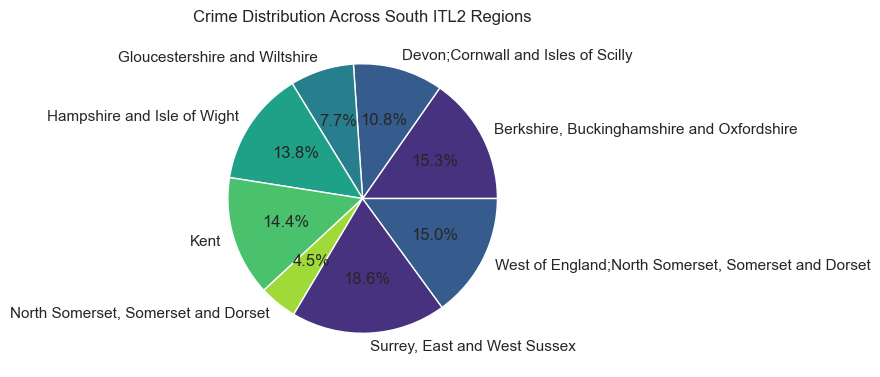

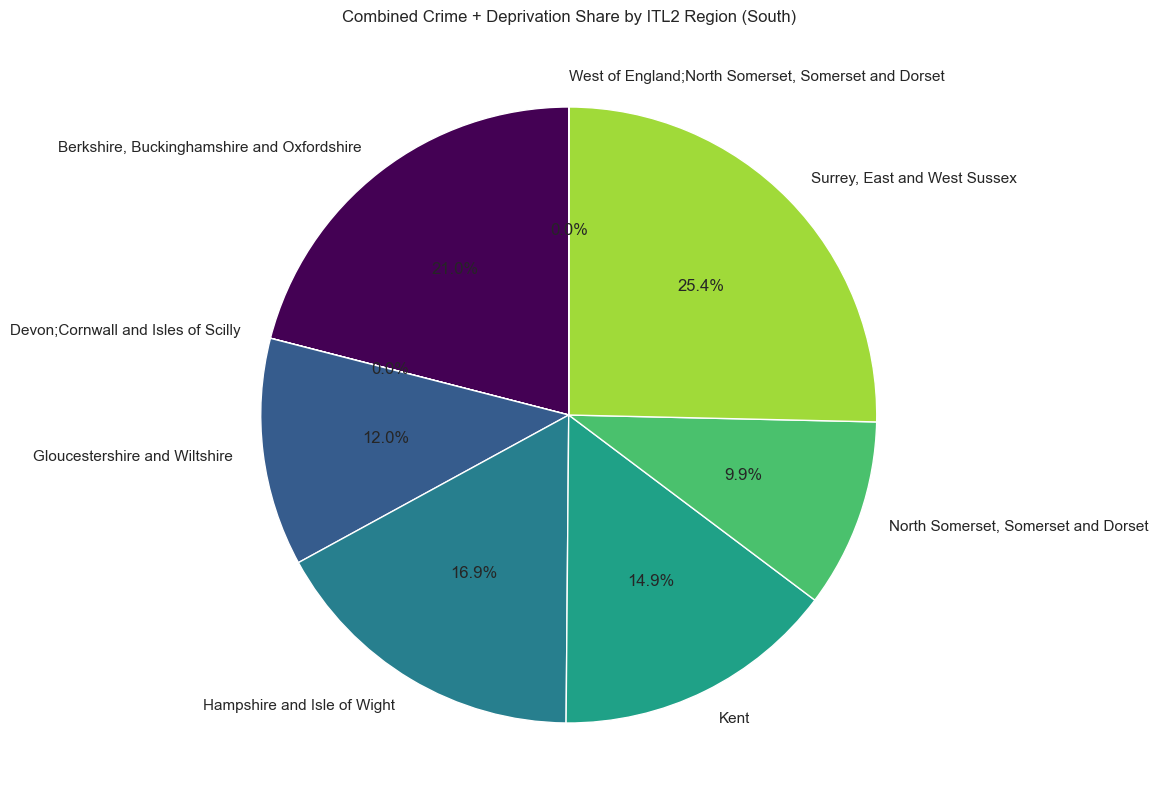

In [107]:
crime = pd.read_csv(
    r"clean_materials\CLEANED-regional_forces_crime_data_2024-2025.csv"
)
# Loading the deprivation dataset using the full file path
deprivation = pd.read_csv(
    r"clean_materials\clean_index_of_multiple_deprivation.csv"
)
# Filtering the crime dataset to only include South East and South West regions
south_df = crime[crime['ITL1 region'].isin(['South East (England)', 'South West (England)'])]

# Checking the first few rows to confirm the filter worked
south_df.head()

# Grouping the South data by ITL2 region and summing the total number of offences
south_itl2 = south_df.groupby('ITL2 region')['Number of Offences'].sum().reset_index()

# Displaying the grouped data
south_itl2

plt.figure(figsize=(8,8))
plt.pie(
    south_itl2['Number of Offences'],
    labels=south_itl2['ITL2 region'],
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis')
)
plt.title('Crime Distribution Across South ITL2 Regions')
plt.tight_layout()
plt.show()

# Combined pie chart showing each region's share of crime and deprivation.

plt.figure(figsize=(10,10))

# Comparing Crime and Deprivation (SOUTH ITL2 REGIONS)
# with the deprivation data (IMD Rank) using the ITL2.
# This allows us to see whether more deprived areas have higher crime.

# Explode the lists
south_itl2_exploded = south_itl2.explode('ITL2 region')

# Keeping only the useful columns from the deprivation dataset
deprivation_clean = deprivation[['ITL1', 'ITL2', 'IMD Rank']]

#Renaming the columns in the datasets to match
deprivation_clean = deprivation_clean.rename(columns={'ITL2': 'ITL2 region'})

# Merging the South ITL2 crime totals with the deprivation data
merged = south_itl2_exploded.merge(deprivation_clean, on='ITL2 region', how='left')

# Showing the merged dataset to confirm the join worked
merged.head()

# Prepare data for the pie chart
crime_share = merged.groupby('ITL2 region')['Number of Offences'].sum()
deprivation_share = merged.groupby('ITL2 region')['IMD Rank'].mean()

# Combine into one DataFrame
combined = pd.DataFrame({
    'Crime Share': crime_share,
    'Deprivation Share': deprivation_share
})

# Normalise deprivation so it behaves like a pie slice
combined['Deprivation Share'] = combined['Deprivation Share'] / combined['Deprivation Share'].sum() * combined['Crime Share'].sum()

# Plot combined pie chart
combined.sum(axis=1).plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    cmap='viridis'
)

plt.ylabel('')
plt.title('Combined Crime + Deprivation Share by ITL2 Region (South)')
plt.show()


## Machine Learning Model
#### It is **essential** that you run the [clean_2026_data.py](machine_learning\clean_2026_data.py) file before you execute this cell, so that the machine learning notebook can be created. This can be found in the machine_learning folder or through the link here.

### Linear Regression Model
 - IMD Rank and Total Offences - by ITL2 regions
 - Utilising 24/25 crime and average IMD data across ITL2 regions to train the model, and more recent 25/26 crime data to predict future IMD rankings
 - This is particularly useful in the real world as IMD rankings are only released every 4-6 years
 - This model will, therefore, provide valuable insights into the potential IMD rankings between publications 

 Basic flow:
 - Choose ML model
 - Select and pre-process the appropiate data
 - Split data into features and target variable (supervised learning)
 - Test / train split
 - K-fold cross validation
 - Train model
 - Test model
 - Model evaluation metrics:
   Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R Squared (R2)
 - Use model on new data

In [108]:
df = pd.read_csv("machine_learning/machine_learning.csv")
print(df.columns)

total_offences = df[["total_offences"]]
imd_ranking = df[["avg_imd_rank_by_ITL2"]]
total_offences = total_offences.to_numpy(copy=True, dtype=int) # # csv files to NumPy array, As required by scikit-learn
imd_ranking = imd_ranking.to_numpy(copy=True, dtype=int)

print(f"Shape: {imd_ranking.shape}")
print(f"Dtype:{imd_ranking.dtype}")

print(f"Shape: {total_offences.shape}")
print(f"Dtype:{total_offences.dtype}")

# Splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(total_offences,
                                    imd_ranking, test_size=0.4, random_state=42)

# Visualising the splits
print('Train / test split:\n')
print(f'X_train: {X_train.shape}\ny_train: {y_train.shape}\n\
        X_test: {X_test.shape}\ny_test: {y_test.shape}')

# Use standard scaler - already imported
scaler = StandardScaler()

# Scaling the X train and test data
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

# Define your K-Fold Cross Validation 'settings'
kf = KFold(n_splits=5, random_state=42, shuffle=True)

# Create your model
model = LinearRegression()


# Utilise K-Fold Cross Validation to assess the model
# First define the metrics you need
scoring = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']

kf_scores = cross_validate(
    model, total_offences, imd_ranking, cv=kf, scoring=scoring)


# for keys in kf_scores:
#     print(keys) # To find the names to call in our print functions

print('Cross validation scores:\n')
print(f'Fit Time: {kf_scores['fit_time'].mean():.2f}') # Rounding to 2 decimal places
print(f'Score Time: {kf_scores['score_time'].mean():.2f}')
print(f'r2: {kf_scores['test_r2'].mean():.2f}')
print(f'MAE: {kf_scores['test_neg_mean_absolute_error'].mean():.2f}')
print(f'RMSE: {kf_scores['test_neg_root_mean_squared_error'].mean():.2f}')

# Fit your model to the entire training split of data 
#(rather than 80% splits as seen with the K-Fold Cross Validation above)
model.fit(scaled_X_train, y_train)

# Use the model to make predictions on your test data
y_pred = model.predict(scaled_X_test)

# Assess the model using the chosen metrics
# R2, MAE, RMSE
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'Test metrics:\nR2: {r2: .2f}\nMAE: {mae: .2f}\nRMSE: {rmse: .2f}')

# Upload new input data - explode 2025-2026 data

## See the clean_2026_data.py file to see how thw 2025-2026 data was cleaned

df_2026 = pd.read_csv("machine_learning/machine_learning_test.csv") # Make sure to run clean_2026_data.py
latest_total_offences = df_2026[["total_offences"]]
latest_total_offences = latest_total_offences.to_numpy(copy=True, dtype=int)


predicted_imd = model.predict(latest_total_offences)
print(predicted_imd)


Index(['ITL2', 'total_offences', 'avg_imd_by_ITL2', 'avg_imd_rank_by_ITL2'], dtype='str')
Shape: (36, 1)
Dtype:int64
Shape: (36, 1)
Dtype:int64
Train / test split:

X_train: (21, 1)
y_train: (21, 1)
        X_test: (15, 1)
y_test: (15, 1)
Cross validation scores:

Fit Time: 0.01
Score Time: 0.00
r2: -0.69
MAE: -2831.22
RMSE: -3305.02
Test metrics:
R2: -0.28
MAE:  2731.02
RMSE:  3139.38
[[-1.23441652e+08]
 [-1.53069214e+08]
 [-6.31189301e+07]
 [-6.93937296e+07]
 [-1.10831421e+08]
 [-3.26627323e+07]
 [-1.67749249e+08]
 [-1.10831421e+08]
 [-8.40868418e+07]
 [-1.29630853e+08]
 [-7.99341562e+07]
 [-2.83431205e+08]
 [-1.37678242e+08]
 [-1.09090931e+08]
 [-8.33251292e+08]
 [-8.41157207e+08]
 [-1.40462550e+08]
 [-1.15550003e+08]
 [-1.33521990e+08]
 [-4.83485420e+07]
 [-1.25373548e+08]
 [-5.25749369e+07]
 [-2.02367644e+08]
 [-4.02904536e+07]
 [-1.77743989e+08]
 [-8.33251292e+08]
 [-8.33251292e+08]
 [-8.33251292e+08]
 [-1.52103861e+08]
 [-1.30885100e+08]
 [-3.94820293e+07]
 [-1.86746032e+08]
 [-

## Machine Learning Model Next steps
Given more time, we would next explore different regression models, compare these models and select the most appropriate.

We understand this model could be significantly more accurate and we would therefore include regional weights and also layered granularity for areas such as London. For example, we may next undertake multiple linear regression, then calculate linear regression coefficients and assess feature importance. Examples of multiple features that we could use for future models, include location (ITL2), offence group and offence subgroup. We could also expand our features, to include input from the wellness dataset, rather than solely the crime dataset. Additionally, given the time, we would undertake this process on both the IMD ranking and IMD decile. 

## Conclusions and recommendations 



### Overall conclusions:

Based on our analysis we have found there is a small correlation between the number of crimes committed in an ITL region and its IMD ranking / decile. However, we've noted that there needs to be more granularity in where the crimes were committed to truly understand the true relationship and to build an effective model.

We also noted there were correlations between crime and wellness data, but did not have enough to feed into our model. In particular average life expectancy in an area proved the most closely linked with the number of crimes. Life expectancy is also linked to how affluent an area is, so it was great to see our hypothesis in action.

This correlation is most prominent for the ITL1 regions and highlights our analysis is most effective on a large scale, as opposed to looking at local trends and patterns.

### Recommendations:
To understand on a more localised scale we would recommend to build a more comprehenesive model that takes into account local nuances (As shown in our Chlorepath map of London). To achieve this the following should be done:
- Launch FOI requests for each police force, to get a more granular view of where crimes were committed - these would allow for a greater deep-dive into areas like "The south" where crime is overall lower.
- Pull old historical IMD data and crime data so that the model can be trained on a larger dataset.
- Use this analysis to highlight the big overall picture.


### Next steps:

Given more time, we would next explore different regression models, compare these models and select the most appropriate.

 We understand this model could be significantly more accurate and we would therefore include regional weights and also layered granularity for areas such as London. For example, we may next undertake multiple linear regression, then calculate linear regression coefficients and assess feature importance. Examples of multiple features that we could use for future models, include location (ITL2), offence group and offence subgroup. We could also expand our features, to include input from the wellness dataset, rather than solely the crime dataset. Additionally, given the time, we would undertake this process on both the IMD ranking and IMD decile. 